<a href="https://colab.research.google.com/github/SI-GRush34/beijing-air-quality-project/blob/main/Beijing-Air-Quality-Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beijing Air Quality Analysis
## Task 1 – Data Selection and Handling

High concentrations of air pollutants like PM2.5, PM10, SO2, NO2, CO, and O3 can cause serious respiratory and cardiovascular diseases. Beijing, the capital city of :contentReference[oaicite:0]{index=0}, has had serious air pollution issues over the past 20 years due to rapid urbanisation, industrialisation, and rising vehicle emissions. The goal of this task is to select and integrate air quality datasets collected from monitoring stations in :contentReference[oaicite:1]{index=1}. Severe respiratory and cardiovascular conditions can result from high levels of air pollutants such PM2.5, PM10, SO2, NO2, CO, and O3. Over the past 20 years, increased urbanisation, industrialisation, and rising car emissions have caused serious air pollution issues in Beijing, the capital city of :contentReference[oaicite:0]{index=0}.

The selection and integration of air quality datasets gathered from monitoring stations in :contentReference[oaicite:1]{index=1} is the main goal of this assignment. The goal is to import, preprocess, and combine several datasets into a single, cohesive dataset that may be used for predictive modelling and additional exploratory data analysis.

## Importing Required Libraries

To facilitate data preprocessing, analysis, and visualisation chores, the following Python libraries were imported: Matplotlib and Seaborn are used for visualisation, while Pandas and NumPy are used for data manipulation and numerical calculations. Matplotlib and Seaborn are used for visualisation, while Pandas and NumPy are utilised for numerical computations and data manipulation.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

## Monitoring Station Selection From the Beijing air quality monitoring network, two urban and two suburban monitoring stations were chosen for this analysis

From the Beijing air quality monitoring network, two urban and two suburban monitoring sites were chosen for this investigation:
Urban Stations: Dongsi and Guanyuan,
Suburban Stations: Changping and Huairou

Dongsi and Guanyuan were chosen as urban stations because they are situated in densely populated central regions of :contentReference[oaicite:2]{index=2}, where traffic congestion, commercial activity, and industrial emissions are relatively high. As a result, these locations are representative of inner-city pollution conditions. Changping and Huairou were chosen as suburban stations because they are located farther from the urban center and are characterised by lower population density and reduced industrial activity. These stations offer a useful comparison between urban and suburban air quality conditions. The categorisation was supported by earlier research, including studies by Xu & Zhang and Yao et al. As a result, these places are typical of pollution levels in inner cities.

Due to their distance from the city center, lower population density, and less industrial activity, Changping and Huairou were chosen as suburban stations. These stations offer a helpful comparison of the quality of the air in cities and suburbs.

Previous research, such as studies by Xu & Zhang and Yao et al., which categorise monitoring locations based on urban and suburban features, was used to support the station classification.

## Importing Selected Air Quality Datasets

The chosen datasets, which include hourly meteorological and air quality measurements gathered between March 2013 and February 2017, were uploaded into the Google Colab environment and imported using the Pandas library.

The Pandas library was used to import the chosen datasets after they were uploaded into the Google Colab environment. Hourly meteorological and air quality data from March 2013 to February 2017 are included in each file.

In [54]:
import os
import pandas as pd

# Get file names
files = os.listdir('/content')

# Create DataFrame
files_df = pd.DataFrame(files, columns=['Available Dataset Files Below'])

# Add numbering
files_df.index = range(1, len(files_df) + 1)

# Display
files_df.style.set_properties(**{
    'text-align': 'left',
    'font-size': '12pt'
}).set_caption("** List of Available Files in the Working Directory **")

,Available Dataset Files Below
1,.config
2,mnist_train_small.csv
3,california_housing_test.csv
4,README.md
5,PRSA_Data_Dongsi_20130301-20170228.csv
6,sample_data
7,mnist_test.csv
8,PRSA_Data_Changping_20130301-20170228.csv
9,PRSA_Data_Guanyuan_20130301-20170228.csv
10,anscombe.json


In [55]:
import pandas as pd

def load_dataset(file_path, station_name):
    df = pd.read_csv(file_path)
    df['station'] = station_name
    return df

dongsi = pd.read_csv('/content/PRSA_Data_Dongsi_20130301-20170228.csv')
guanyuan = pd.read_csv('/content/PRSA_Data_Guanyuan_20130301-20170228.csv')
changping = pd.read_csv('/content/PRSA_Data_Changping_20130301-20170228.csv')
huairou = pd.read_csv('/content/PRSA_Data_Huairou_20130301-20170228.csv')

print("All the datasets loaded successfully!!!")

All the datasets loaded successfully!!!


## Dataset Preview

The first 5 rows of the Dongsi monitoring station dataset are shown in the output that follows. This preview aids in confirming that the dataset has been successfully imported into the development environment.

In [56]:
print("Dongsi Dataset")
display(dongsi.head())

print("Guanyuan Dataset")
display(guanyuan.head())

print("Changping Dataset")
display(changping.head())

print("Huairou Dataset")
display(huairou.head())

print(dongsi.shape)

Dongsi Dataset


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


Guanyuan Dataset


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


Changping Dataset


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


Huairou Dataset


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


(35064, 18)


## Comprehending Dataset Structure

Dataset Information:

Prior to carrying out preprocessing and merging procedures, it is crucial to comprehend the dataset structure, which was analysed to determine the number of records, column names, data kinds, and missing values.

In [57]:
def styled_summary(df, name):
    summary = pd.DataFrame({
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Missing Values': df.isnull().sum().values,
        'Non-Null Count': df.notnull().sum().values
    })

    display(
        summary.style
        .set_caption(f"{name} Dataset Information Summary")
        .background_gradient(cmap='Blues')
        .set_properties(**{
            'text-align': 'center',
            'font-size': '11pt'
        })
    )

styled_summary(dongsi, "Dongsi")
styled_summary(guanyuan, "Guanyuan")
styled_summary(changping, "Changping")
styled_summary(huairou, "Huairou")

,Column Name,Data Type,Missing Values,Non-Null Count
0,No,int64,0,35064
1,year,int64,0,35064
2,month,int64,0,35064
3,day,int64,0,35064
4,hour,int64,0,35064
5,PM2.5,float64,750,34314
6,PM10,float64,553,34511
7,SO2,float64,663,34401
8,NO2,float64,1601,33463
9,CO,float64,3197,31867


,Column Name,Data Type,Missing Values,Non-Null Count
0,No,int64,0,35064
1,year,int64,0,35064
2,month,int64,0,35064
3,day,int64,0,35064
4,hour,int64,0,35064
5,PM2.5,float64,616,34448
6,PM10,float64,429,34635
7,SO2,float64,474,34590
8,NO2,float64,659,34405
9,CO,float64,1753,33311


,Column Name,Data Type,Missing Values,Non-Null Count
0,No,int64,0,35064
1,year,int64,0,35064
2,month,int64,0,35064
3,day,int64,0,35064
4,hour,int64,0,35064
5,PM2.5,float64,774,34290
6,PM10,float64,582,34482
7,SO2,float64,628,34436
8,NO2,float64,667,34397
9,CO,float64,1521,33543


,Column Name,Data Type,Missing Values,Non-Null Count
0,No,int64,0,35064
1,year,int64,0,35064
2,month,int64,0,35064
3,day,int64,0,35064
4,hour,int64,0,35064
5,PM2.5,float64,953,34111
6,PM10,float64,777,34287
7,SO2,float64,980,34084
8,NO2,float64,1639,33425
9,CO,float64,1422,33642


## Finding Missing Values

In order to assess the quality of the data and ascertain whether preprocessing methods would be necessary prior to analysis and predictive modelling, missing values were looked at.

In [58]:
import pandas as pd

# Function to display missing values summary
def missing_values_summary(df, name):

    missing_df = pd.DataFrame({
        'Column Name': df.columns,
        'Missing Values': df.isnull().sum().values
    })

    print(f"\n{name} Dataset - Missing Values Summary")

    display(
        missing_df.style
        .background_gradient(cmap='Reds')
        .set_caption(f"{name} Missing Values Report")
        .set_properties(**{
            'text-align': 'center',
            'font-size': '11pt'
        })
    )

# Display summaries
missing_values_summary(dongsi, "Dongsi")
missing_values_summary(guanyuan, "Guanyuan")
missing_values_summary(changping, "Changping")
missing_values_summary(huairou, "Huairou")


Dongsi Dataset - Missing Values Summary


,Column Name,Missing Values
0,No,0
1,year,0
2,month,0
3,day,0
4,hour,0
5,PM2.5,750
6,PM10,553
7,SO2,663
8,NO2,1601
9,CO,3197



Guanyuan Dataset - Missing Values Summary


,Column Name,Missing Values
0,No,0
1,year,0
2,month,0
3,day,0
4,hour,0
5,PM2.5,616
6,PM10,429
7,SO2,474
8,NO2,659
9,CO,1753



Changping Dataset - Missing Values Summary


,Column Name,Missing Values
0,No,0
1,year,0
2,month,0
3,day,0
4,hour,0
5,PM2.5,774
6,PM10,582
7,SO2,628
8,NO2,667
9,CO,1521



Huairou Dataset - Missing Values Summary


,Column Name,Missing Values
0,No,0
1,year,0
2,month,0
3,day,0
4,hour,0
5,PM2.5,953
6,PM10,777
7,SO2,980
8,NO2,1639
9,CO,1422


To identify the matching air quality monitoring station, a new column called station was introduced to each dataset. When combining several datasets, this phase is crucial since it allows for comparison analysis between various monitoring locations while maintaining the source information of each observation.

In [59]:
dongsi['station'] = 'Dongsi'
guanyuan['station'] = 'Guanyuan'
changping['station'] = 'Changping'
huairou['station'] = 'Huairou'

In order to preserve station-specific observations while guaranteeing that only true duplicate rows are eliminated from the dataset, the datasets from various monitoring stations were first combined into a single DataFrame using pd.concat(). Duplicate records were then found using the duplicated() function and eliminated using drop_duplicates().

In [60]:
# Combine all datasets
combined_df = pd.concat([dongsi, guanyuan, changping, huairou], ignore_index=True)

# Duplicate rows
print("Number of duplicate rows:", combined_df.duplicated().sum())

# Remove duplicate rows
combined_df.drop_duplicates(inplace=True)

# Verify duplicates after removal
print("Duplicate rows after removal:", combined_df.duplicated().sum())

Number of duplicate rows: 0
Duplicate rows after removal: 0


## Handling Timestamps



The year, month, day, and hour columns in the original dataset each contain temporal information separately. To enhance time-series analysis and streamline merging procedures, these columns were merged into a single datetime column using Pandas datetime capabilities.

In [61]:
import pandas as pd

# Function to create datetime column
def create_datetime(df):
    df['datetime'] = pd.to_datetime(
        df[['year', 'month', 'day', 'hour']]
    )
    return df

# Apply function
dongsi = create_datetime(dongsi)
guanyuan = create_datetime(guanyuan)
changping = create_datetime(changping)
huairou = create_datetime(huairou)

# Add station labels
dongsi['station'] = 'Dongsi'
guanyuan['station'] = 'Guanyuan'
changping['station'] = 'Changping'
huairou['station'] = 'Huairou'

# Merge datasets
combined_df = pd.concat(
    [dongsi, guanyuan, changping, huairou],
    ignore_index=True
)

timestamp_preview = combined_df[['datetime', 'station']].head(10)
display(
    timestamp_preview.style
    .set_caption("📅 Air Quality Timestamp Handling with Station Info")
    .background_gradient(cmap="plasma")
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12pt'
    })
    .highlight_max(axis=0, color='skyblue')
)

,datetime,station
0,2013-03-01 00:00:00,Dongsi
1,2013-03-01 01:00:00,Dongsi
2,2013-03-01 02:00:00,Dongsi
3,2013-03-01 03:00:00,Dongsi
4,2013-03-01 04:00:00,Dongsi
5,2013-03-01 05:00:00,Dongsi
6,2013-03-01 06:00:00,Dongsi
7,2013-03-01 07:00:00,Dongsi
8,2013-03-01 08:00:00,Dongsi
9,2013-03-01 09:00:00,Dongsi


In [62]:
def create_datetime(df):
    df['datetime'] = pd.to_datetime(
        df[['year', 'month', 'day', 'hour']]
    )
    return df

In [63]:
dongsi = create_datetime(dongsi)
guanyuan = create_datetime(guanyuan)
changping = create_datetime(changping)
huairou = create_datetime(huairou)

In [64]:
dongsi[['datetime']].head()

,datetime
0,2013-03-01 00:00:00
1,2013-03-01 01:00:00
2,2013-03-01 02:00:00
3,2013-03-01 03:00:00
4,2013-03-01 04:00:00


## Combining and Merging Certain Datasets

The Pandas concat() function was used to combine the four chosen datasets into a single, cohesive dataframe. Comparative study between urban and suburban monitoring stations is made possible by combining the datasets.

To ensure data persistence for future analysis, the merged dataset was saved as a CSV file using the to_csv() function. The structure of the dataset was then confirmed using the.shape attribute, which provides the total number of rows and columns after merging multiple station datasets. Lastly, the first five records were displayed using the.head() function to confirm successful integration and to provide an initial view of the combined air quality dataset. The results were presented in a formatted and visually enhanced table to improve readability and interpretability.

In [65]:
dongsi['station'] = 'Dongsi'
guanyuan['station'] = 'Guanyuan'
changping['station'] = 'Changping'
huairou['station'] = 'Huairou'

In [66]:
import pandas as pd

# Save merged dataset to CSV
combined_df.to_csv('combined_air_quality.csv', index=False)

# Print dataset shape
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": combined_df.shape
}).T

print("📌 Merged Dataset Overview")

display(
    shape_df.style
    .set_caption("📊 Dataset Shape Summary")
    .background_gradient(cmap="Blues")
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt"
    })
)

# Show first 5 rows
display(
    combined_df.head().style
    .set_caption("🌫️ First 5 Records of Combined Air Quality Dataset")
    .background_gradient(cmap="Greens")
)

📌 Merged Dataset Overview


,0,1
Metric,Rows,Columns
Value,140256,19


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,9.000000,9.000000,3.000000,17.000000,300.000000,89.000000,-0.500000,1024.500000,-21.400000,0.000000,NNW,5.700000,Dongsi,2013-03-01 00:00:00
1,2,2013,3,1,1,4.000000,4.000000,3.000000,16.000000,300.000000,88.000000,-0.700000,1025.100000,-22.100000,0.000000,NW,3.900000,Dongsi,2013-03-01 01:00:00
2,3,2013,3,1,2,7.000000,7.000000,nan,17.000000,300.000000,60.000000,-1.200000,1025.300000,-24.600000,0.000000,NNW,5.300000,Dongsi,2013-03-01 02:00:00
3,4,2013,3,1,3,3.000000,3.000000,5.000000,18.000000,nan,nan,-1.400000,1026.200000,-25.500000,0.000000,N,4.900000,Dongsi,2013-03-01 03:00:00
4,5,2013,3,1,4,3.000000,3.000000,7.000000,nan,200.000000,84.000000,-1.900000,1027.100000,-24.500000,0.000000,NNW,3.200000,Dongsi,2013-03-01 04:00:00


## Task 2 – Exploratory Data Analysis (EDA)

# 2.1 Data Understanding

The Beijing Air Quality dataset was used in this study to find patterns, identify missing values, comprehend pollutant distributions, and obtain insights into environmental conditions. Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that is used to understand the structure, quality, and characteristics of the dataset before applying machine learning or statistical techniques. To find trends, find missing information, comprehend pollutant distributions, and learn more about environmental conditions, this study used EDA on the Beijing Air Quality dataset.

#Import Libraries

The necessary Python libraries for data analysis and visualisation throughout the project are imported in this part. These libraries include features for numerical calculations, data manipulation, and graphical display of the air quality dataset.

Importing these libraries at the start of the notebook helps maintain an organised workflow and guarantees that all necessary tools are available for subsequent preprocessing, analysis, and model development tasks.

- `pandas` is used for handling and analysing structured data in tabular format;
- `numpy` supports numerical and mathematical operations efficiently;
- `matplotlib.pyplot` is used for creating basic charts and visualisations;
- `seaborn` offers advanced statistical visualisations with improved aesthetics;
 - `pd.set_option('display.max_columns', None)` guarantees that all columns in the dataset are displayed without truncation for better data inspection and understanding.

 Reason for importing these libraries at the start of the notebook guarantees that all necessary tools are available for ensuing preprocessing, analysis, and model construction tasks and helps maintain an ordered workflow.

In [67]:
print("-" * 40)
print(" Import Required Libraries ")
print(" ***************************** ")
print("Libraries Imported Successfully!!!")
print("-" * 40)
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)

----------------------------------------
 Import Required Libraries 
 ***************************** 
Libraries Imported Successfully!!!
----------------------------------------


#Load Dataset

The combined air quality dataset, which includes meteorological variables and air pollution measurements gathered from several monitoring stations during a given time period, is loaded into the Python environment in this section for additional analysis and processing. The dataset includes meteorological variables and measurements of air pollutants that were gathered over a given time period from several monitoring stations.

The CSV file is read by the `pandas` library and stored in a DataFrame called `df`, which offers an organised tabular format for effective data handling and analysis.

Because it enables the data to be examined, cleansed, analysed, and visualised throughout the project, effectively loading the dataset is a crucial first step. Before beginning preprocessing, exploratory data analysis (EDA), and machine learning activities, this phase also guarantees that the dataset is properly connected to the notebook.

In [68]:
print("-" * 40)
print(" Load Dataset")
print(" ***************************** ")
print("Dataset Loaded Successfully!!!")
print("-" * 40)

df = pd.read_csv("combined_air_quality.csv")

----------------------------------------
 Load Dataset
 ***************************** 
Dataset Loaded Successfully!!!
----------------------------------------


#Dataset Shape

By counting the total number of rows and columns in the dataset, this part gives a rudimentary picture of its structure. Determining the quantity of the data and the number of variables available for analysis depends on an understanding of the dataset shape.

The dataset dimensions, where rows stand for observations and columns for characteristics or variables, are retrieved using the `.shape` function. To enhance presentation and readability, the findings are then shown in a structured table.

In [69]:
print(" ============================== ")
print("📊 Dataset Overview")
print(" ============================== ")

rows, columns = df.shape

shape_df = pd.DataFrame({
    "Description": ["Number of Rows", "Number of Columns"],
    "Count": [rows, columns]
})

shape_df.style \
    .set_properties(**{
        'background-color': '#f8f9fa',
        'color': '#000000',
        'border-color': 'black',
        'text-align': 'center'
    }) \
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#0d6efd'),
                ('color', 'white'),
                ('font-size', '14px'),
                ('text-align', 'center')
            ]
        }
    ])

📊 Dataset Overview


,Description,Count
0,Number of Rows,140256
1,Number of Columns,19


#Displaying First 5 Records

To get a general idea of the data structure, column names, and sample values, this section shows the dataset's first five rows. Previewing the dataset enables early detection of possible problems, such as missing numbers or incorrect formatting, and helps confirm that the data has been loaded correctly.

The first five rows are retrieved using the `head()` function, and table styling is employed to enhance the notebook's readability and presentation quality.

In [70]:
print(" ============================== ")
print(" Display First 5 Rows ")
print(" ============================== ")

df.head().style \
    .background_gradient(cmap='Blues') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

 Display First 5 Rows 


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,9.000000,9.000000,3.000000,17.000000,300.000000,89.000000,-0.500000,1024.500000,-21.400000,0.000000,NNW,5.700000,Dongsi,2013-03-01 00:00:00
1,2,2013,3,1,1,4.000000,4.000000,3.000000,16.000000,300.000000,88.000000,-0.700000,1025.100000,-22.100000,0.000000,NW,3.900000,Dongsi,2013-03-01 01:00:00
2,3,2013,3,1,2,7.000000,7.000000,nan,17.000000,300.000000,60.000000,-1.200000,1025.300000,-24.600000,0.000000,NNW,5.300000,Dongsi,2013-03-01 02:00:00
3,4,2013,3,1,3,3.000000,3.000000,5.000000,18.000000,nan,nan,-1.400000,1026.200000,-25.500000,0.000000,N,4.900000,Dongsi,2013-03-01 03:00:00
4,5,2013,3,1,4,3.000000,3.000000,7.000000,nan,200.000000,84.000000,-1.900000,1027.100000,-24.500000,0.000000,NNW,3.200000,Dongsi,2013-03-01 04:00:00


#Coloumn Names

In order to comprehend the variables contained in the air quality data, this section shows all column names that are present in the dataset. In order to identify pollutant measurements, climatic characteristics, and time-related variables that will be utilised during data analysis and model construction, it is crucial to identify column names.

To enhance readability and give a more comprehensive picture of the dataset structure, the column names are arranged in a structured table.





In [71]:
print("-" * 40)
print("  Column Names ")
print("-" * 40)

columns_df = pd.DataFrame({
    "Column Names": df.columns
}).T

columns_df.style \
    .background_gradient(cmap='viridis') \
    .set_properties(**{
        'text-align': 'left',
        'font-size': '13px'
    })

----------------------------------------
  Column Names 
----------------------------------------


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Column Names,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime


# Duplicates Values

In order to guarantee data integrity prior to additional analysis, this component finds and counts duplicate rows in the dataset. Because duplicate data introduce bias or over-represent some observations, they can have a negative impact on statistical results and machine learning models.

We can determine whether data cleaning procedures, like eliminating duplicates, are required by computing the total number of duplicate rows. This guarantees that every record in the dataset is distinct and appropriately contributes to the analysis procedure.

For improved readability and interpretation, the outcome is presented in an organised, aesthetically pleasing fashion.

In [72]:
duplicate_df = pd.DataFrame({
    "Metric": ["Total Duplicate Rows"],
    "Count": [df.duplicated().sum()]
})

duplicate_df.style \
    .background_gradient(cmap='Oranges') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

,Metric,Count
0,Total Duplicate Rows,0


## Datetime Structure

Datetime-related variables were examined to guarantee proper temporal formatting for time-series analysis, and duplicate observations were eliminated from the dataset to enhance data quality and avoid biased analytical conclusions.To guarantee correctness and avoid duplication bias in statistical results, duplicate records were eliminated.

To help you understand the structure of time-based data, this section presents a sample of the dataset's datetime-related columns. Correctly formatted temporal variables are crucial for trend analysis, seasonal pattern detection, and forecasting activities because this is a time-series dataset.

We can verify that the dataset is appropriately organised for time-based analysis by looking over the `datetime`, `year`, `month`, and `day` columns. This stage contributes to the accuracy and dependability of subsequent processes including grouping, resampling, and time-based visualisation.

To enhance readability and presentation, the data is also structured in a clear tabular view.

In [73]:
df[['datetime', 'year', 'month', 'day']].head(10).style \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'center')]
    }])

,datetime,year,month,day
0,2013-03-01 00:00:00,2013,3,1
1,2013-03-01 01:00:00,2013,3,1
2,2013-03-01 02:00:00,2013,3,1
3,2013-03-01 03:00:00,2013,3,1
4,2013-03-01 04:00:00,2013,3,1
5,2013-03-01 05:00:00,2013,3,1
6,2013-03-01 06:00:00,2013,3,1
7,2013-03-01 07:00:00,2013,3,1
8,2013-03-01 08:00:00,2013,3,1
9,2013-03-01 09:00:00,2013,3,1


# Missing Values

A sample of the dataset and a brief summary of data completeness are presented in this section. To evaluate the dataset's quality and spot any data gaps that can interfere with additional analysis or model construction, the total number of missing values is computed.

Understanding missing values is crucial because improper handling of partial data can affect statistical outcomes and lower model accuracy.

Additionally, the dataset's first five rows are shown to give a brief overview of the data's structure, column values, and general format. To make it simpler to visually examine the dataset within the notebook, a colour gradient is used to draw attention to missing or lower-value patterns.

In [74]:
print("-" * 40)
print("\nMissing Values:", df.isnull().sum().sum())
print("-" * 40)
display(df.head()
    .style
    .background_gradient(cmap='Reds', axis=1)
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [
            ('background-color', 'black'),
            ('color', 'white'),
            ('text-align', 'center')
        ]
    }]))

----------------------------------------

Missing Values: 25530
----------------------------------------


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,9.000000,9.000000,3.000000,17.000000,300.000000,89.000000,-0.500000,1024.500000,-21.400000,0.000000,NNW,5.700000,Dongsi,2013-03-01 00:00:00
1,2,2013,3,1,1,4.000000,4.000000,3.000000,16.000000,300.000000,88.000000,-0.700000,1025.100000,-22.100000,0.000000,NW,3.900000,Dongsi,2013-03-01 01:00:00
2,3,2013,3,1,2,7.000000,7.000000,nan,17.000000,300.000000,60.000000,-1.200000,1025.300000,-24.600000,0.000000,NNW,5.300000,Dongsi,2013-03-01 02:00:00
3,4,2013,3,1,3,3.000000,3.000000,5.000000,18.000000,nan,nan,-1.400000,1026.200000,-25.500000,0.000000,N,4.900000,Dongsi,2013-03-01 03:00:00
4,5,2013,3,1,4,3.000000,3.000000,7.000000,nan,200.000000,84.000000,-1.900000,1027.100000,-24.500000,0.000000,NNW,3.200000,Dongsi,2013-03-01 04:00:00


# Data Types

In order to comprehend how the variables are kept and how they might be utilised for analysis, this section identifies the data types of each column in the dataset. Understanding data types is crucial since it guarantees that the right preprocessing methods are used and helps identify which columns are numerical, categorical, or datetime-based.

For instance, whereas categorical columns might need to be encoded before additional processing, numerical columns can be used for statistical analysis and machine learning models.

To enhance readability and facilitate the interpretation of the dataset structure, the results are presented in an organised fashion with visual styling.

In [75]:
print("-" * 40)
print("  Data Types ")
print("-" * 40)

dtype_df = pd.DataFrame(df.dtypes, columns=['Data Type']).T

dtype_df.style \
    .background_gradient(cmap='coolwarm') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

----------------------------------------
  Data Types 
----------------------------------------


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
Data Type,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,float64,object,object


# Data Type Count

The number of columns that belong to each type of data in the dataset is summarised in this section. This summary makes it easier to immediately comprehend the overall structure of the dataset in terms of numerical, categorical, and other variable kinds rather than focusing on specific column types.

This helps determine whether encoding, type conversion, or scaling may be necessary prior to doing analysis or developing machine learning models, which is helpful during the data preprocessing step. To improve readability and clarity, the output is also formatted as a structured table.

In [76]:
df.dtypes.value_counts().reset_index().rename(
    columns={"index": "Data Type", 0: "Count"}
)

,Data Type,count
0,float64,11
1,int64,5
2,object,3


# Verifying Missing Values

After the initial inspection or preprocessing stages, this phase is used to double-check and confirm whether the dataset contains any missing values. By determining whether any missing values are still present and may require additional treatment prior to analysis or model construction, it aids in ensuring data quality.

Because it guarantees that the dataset is complete and consistent and lowers the possibility of errors or bias in subsequent phases like statistical analysis or machine learning modelling, verifying missing values is a crucial step in the data cleaning process.

To facilitate the interpretation of the remaining missing data across all variables, the findings are presented in an organised fashion with a visual gradient.

In [77]:
print("-" * 40)
print("  Verify Missing Values ")
print("-" * 40)

verify_missing = pd.DataFrame(
    df.isnull().sum(),
    columns=['Remaining the Missing Values']
)

verify_missing.style \
    .background_gradient(cmap='Reds') \
    .set_properties(**{
        'text-align': 'center'
    })

----------------------------------------
  Verify Missing Values 
----------------------------------------


,Remaining the Missing Values
No,0
year,0
month,0
day,0
hour,0
PM2.5,3093
PM10,2341
SO2,2745
NO2,4566
CO,7893


** Pollutant concentration variations, missing values, and possible correlations between pollution and meteorological variables are all indicated by preliminary study.

Significant variance in pollutant levels, especially PM2.5 and PM10, is shown in the statistical summary, reflecting varying air quality conditions throughout the dataset.

The table below provides a thorough statistical summary of the air quality dataset, which contains hourly observations from 2013 to 2017. It comprises climatic conditions, air pollution concentrations, and temporal variables. In order to comprehend environmental trends and get the dataset ready for additional analysis, each column offers information about the distribution, variability, and quality of the data.

The number of valid observations for each variable is displayed in the "count" row. A handful of pollutants, including PM2.5, PM10, SO2, NO2, CO, and O3, have missing data, even though the majority of variables have roughly 140,256 entries. This underlines the need for preprocessing, such as imputation or the elimination of missing values, and indicates data loss that is probably caused by sensor malfunction, environmental interference, or recording problems.

The hour variable verifies a full 24-hour cycle of observations, which is crucial for time-series analysis, while the mean year value (2014.66) shows that data is distributed throughout the entire time range. The temporal variables (year, month, day, and hour) confirm that the dataset spans multiple years (2013–2017) with uniform hourly recordings.

The mean concentration of PM2.5 (fine particulate matter) is 77.48, with values ranging from 2 to 882. The high maximum value and large standard deviation (78.36) show strong variability and extreme pollution episodes; the distribution is right-skewed because the median (50%) is lower than the mean, indicating that occasional severe pollution events have a significant impact on average levels.

Likewise, PM10 (coarse particulate matter) exhibits extremely significant pollution spikes, with a mean of 101.40 and a maximum of 999. Both typical air conditions and severe dust or industrial pollution occurrences are suggested by the large range. A skewed distribution is also supported by the discrepancy between the mean and median (79).

The gaseous pollutants exhibit varying degrees of variability: NO2 (nitrogen dioxide) has a mean of 47.13 and a maximum of 270, reflecting traffic-related emissions with moderate variability and a comparatively higher proportion of missing data compared to other pollutants; SO2 (sulphur dioxide) has a relatively low mean (15.81) but a high maximum (315), suggesting mostly stable conditions with sporadic industrial emission spikes.

O3 (Ozone) shows a mean of 57.69 but a very high maximum value (1071), which may indicate unusual atmospheric reactions or potential outliers/sensor anomalies. Ozone levels are usually influenced by sunlight and temperature, which explains their variability. CO (Carbon Monoxide) shows a very high mean value (1192) with a maximum reaching 10,000, indicating significant variability and potential pollution peaks caused by combustion activities like traffic congestion and fuel burning. The large standard deviation confirms that CO levels vary greatly over time.

Environmental context is provided by the meteorological variables. Temperature (TEMP) ranges from -19.9°C to 41.4°C with a mean of 13.35°C, indicating that all seasonal variations are captured in the dataset. Atmospheric pressure (PRES) stays relatively stable around 1009 hPa with minor fluctuations, which is typical for natural atmospheric conditions.

Rainfall (RAIN) has a very low mean (0.064), meaning that most hours have no rainfall but occasionally heavy rain events occur (up to 72.5), which can significantly affect air pollution levels by washing out particles. Dew Point (DEWP) has a mean of 2.32°C with a wide range, including very low values (-43.4°C), indicating dry atmospheric conditions during certain periods.

Lastly, Wind Speed (WSPM) has a mean of 1.77 m/s, which indicates usually low wind conditions. While greater wind speeds aid in dispersion and enhance air quality, lower wind speeds can lead to pollutant concentration.

Overall, the dataset demonstrates that while meteorological variables offer steady environmental background, air pollution variables are severely skewed with extreme values and missing records. These features emphasise how crucial it is to clean the data, handle outliers, and do additional correlation analysis before creating predictive models.


In [78]:
print("-" * 40)
print("  Statistical Summary ")
print("-" * 40)

df.describe().style \
    .background_gradient(cmap='PuBu') \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12px'
    })

----------------------------------------
  Statistical Summary 
----------------------------------------


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,137163.000000,137915.000000,137511.000000,135690.000000,132363.000000,136664.000000,140112.000000,140113.000000,140110.000000,140110.000000,140136.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,77.481501,101.399508,15.811354,47.129503,1192.068962,57.692177,13.347028,1009.939314,2.328893,0.064937,1.768796
std,10122.141000,1.177201,3.448715,8.800123,6.922211,78.366874,89.753213,21.822958,32.961087,1100.290695,56.140181,11.506183,10.479821,13.856002,0.826774,1.252547
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,35.000000,2.000000,22.000000,500.000000,13.000000,3.000000,1001.500000,-9.200000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,53.000000,79.000000,7.000000,39.000000,900.000000,45.000000,14.300000,1009.500000,2.900000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,108.000000,141.000000,20.000000,65.696000,1500.000000,81.000000,23.100000,1018.100000,15.000000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,882.000000,999.000000,315.000000,270.000000,10000.000000,1071.000000,41.400000,1042.000000,29.100000,72.500000,12.900000


## Task 2.2. Data preprocessing

This section focuses on using crucial data preparation techniques to get the raw air quality dataset ready for additional analysis and modelling. In order to increase the quality and dependability of real-world environmental data, it is crucial to clean and modify the information because it frequently contains errors, missing values, and redundant records.
Managing missing values, eliminating duplicate entries, and carrying out feature engineering tasks like extracting helpful datetime components (year, month, day, and hour) are all part of the preprocessing procedure. To more accurately depict air quality situations, derived variables like AQI-related features might be developed.

These procedures guarantee that the dataset is consistent, well-structured, and appropriate for precise statistical analysis, machine learning model construction, and visualisation.

## Dataset Before Cleaning

Before performing any data cleaning procedures, this section documents the dataset's original size. It displays all of the rows and columns in the raw dataset.

Because it offers a baseline for comparison following preprocessing, capturing the dataset form prior to cleaning is crucial. This aids in determining the extent to which data was impacted by cleaning procedures like eliminating duplicates, managing missing values, or eliminating incorrect information.

We may assess the effect of preprocessing on the total dataset size and make sure that data quality has been enhanced without needlessly sacrificing crucial information by comparing the dataset shape before and after cleaning.

In [79]:
print("-" * 40)
print(" Dataset Shape Before Cleaning ")
print("-" * 40)
before_rows, before_cols = df.shape

before_df = pd.DataFrame({
    "Description": ["Rows Before Cleaning", "Columns Before Cleaning"],
    "Count": [before_rows, before_cols]
})

before_df.style \
    .background_gradient(cmap='Blues') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

----------------------------------------
 Dataset Shape Before Cleaning 
----------------------------------------


,Description,Count
0,Rows Before Cleaning,140256
1,Columns Before Cleaning,19


## Missing Values (Before Cleaning)

In [80]:
print("-" * 40)
print(" Missing Values Check ")
print("-" * 40)

missing_values = pd.DataFrame(
    df.isnull().sum(),
    columns=['Missing Values']
)

missing_values.style \
    .background_gradient(cmap='Reds') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

----------------------------------------
 Missing Values Check 
----------------------------------------


,Missing Values
No,0
year,0
month,0
day,0
hour,0
PM2.5,3093
PM10,2341
SO2,2745
NO2,4566
CO,7893


## Duplicate Records (Before Cleaning)

Before doing any data cleaning procedures, this section determines how many duplicate records are in the dataset. If duplicate items are not appropriately managed, they may result in biased or inaccurate analysis. Duplicate entries might arise via data gathering or merging processes.

At this point, identifying duplicates aids in determining how redundant the original dataset is. In order to guarantee that every observation is distinct and accurately contributes to the analysis, these duplicate data are usually eliminated during the preprocessing phase.

After duplicates are eliminated during the thorough cleaning procedure, this phase offers a baseline for comparison.

In [81]:
print("-" * 40)
print(" Duplicate Record ")
print("-" * 40)

duplicates = df.duplicated().sum()

duplicate_df = pd.DataFrame({
    "Description": ["Duplicate Records"],
    "Count": [duplicates]
})

duplicate_df.style \
    .background_gradient(cmap='Oranges') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

----------------------------------------
 Duplicate Record 
----------------------------------------


,Description,Count
0,Duplicate Records,0


##  Feature Engineering (Datetime Enhancements)

In order to improve the dataset for further in-depth analysis, this section focuses on feature engineering, which involves creating new relevant variables from the current datetime information. Extracting time-based features makes it easier to spot patterns and trends because air quality data is time-dependent.

To facilitate time-series operations, the `datetime` column is first transformed into an appropriate datetime format. To comprehend daily and monthly trends in air pollution levels, extra features like `day_name` and `month_name` are derived from this. Additionally, by mapping the months into seasonal groups (Winter, Spring, Summer, Autumn), a new component called "season" is developed that aids in the analysis of seasonal differences in air quality.

By adding contextual information, these changes enhance the dataset and make it better suited for statistical analysis, machine learning modelling, and visualisation.

In [82]:
print("-" * 40)
print(" Feature Engineering ")
print("-" * 40)

df['datetime'] = pd.to_datetime(df['datetime'])
df['day_name'] = df['datetime'].dt.day_name()
df['month_name'] = df['datetime'].dt.month_name()
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

df[['datetime', 'day_name', 'month_name', 'season']].head().style \
    .background_gradient(cmap='coolwarm')

----------------------------------------
 Feature Engineering 
----------------------------------------


,datetime,day_name,month_name,season
0,2013-03-01 00:00:00,Friday,March,Spring
1,2013-03-01 01:00:00,Friday,March,Spring
2,2013-03-01 02:00:00,Friday,March,Spring
3,2013-03-01 03:00:00,Friday,March,Spring
4,2013-03-01 04:00:00,Friday,March,Spring


##  AQI Category Classification

PM2.5 levels are mapped by the classification function into pre-established Air Quality Index (AQI) categories, including Good, Moderate, Unhealthy, and Hazardous. Better decision-making and visualisation are supported by this transformation, which aids in the interpretation of air quality situations in a format that is legible by humans.

The generated AQI categories can then be applied to machine learning classification tasks, trend identification, and comparison analysis.

In [83]:
print("-" * 40)
print(" AQI Category Classification ")
print("-" * 40)

def categorize_aqi(pm25):

    if pm25 <= 50:
        return 'Good'

    elif pm25 <= 100:
        return 'Moderate'

    elif pm25 <= 150:
        return 'Unhealthy for Sensitive Groups'

    elif pm25 <= 200:
        return 'Unhealthy'

    elif pm25 <= 300:
        return 'Very Unhealthy'

    else:
        return 'Hazardous'

df['AQI_Level'] = df['PM2.5'].apply(categorize_aqi)

df[['PM2.5', 'AQI_Level']].head(10).style \
    .background_gradient(cmap='RdYlGn_r')

----------------------------------------
 AQI Category Classification 
----------------------------------------


,PM2.5,AQI_Level
0,9.000000,Good
1,4.000000,Good
2,7.000000,Good
3,3.000000,Good
4,3.000000,Good
5,4.000000,Good
6,5.000000,Good
7,3.000000,Good
8,3.000000,Good
9,3.000000,Good


## Dataset Shape After Cleaning

Understanding how preprocessing affects the dataset can be achieved by comparing its form before and after cleaning. It guarantees that the cleaning procedure has enhanced data quality while preserving enough information for analysis and modelling, and it gives insight into the amount of data that was kept.

In [84]:
print("-" * 40)
print(" Dataset Shape After Cleaning ")
print("-" * 40)

after_rows, after_cols = df.shape

after_df = pd.DataFrame({
    "Description": ["Rows After Cleaning", "Columns After Cleaning"],
    "Count": [after_rows, after_cols]
})

after_df.style \
    .background_gradient(cmap='Greens') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

----------------------------------------
 Dataset Shape After Cleaning 
----------------------------------------


,Description,Count
0,Rows After Cleaning,140256
1,Columns After Cleaning,23


## Final Dataset Preview

After all data pretreatment and feature engineering procedures are finished, this section shows the dataset's final preview. Verifying that all transformations, including resolving missing values, eliminating duplication, and adding new features (such datetime components and AQI categories), have been implemented correctly is helpful.

Examining the finished dataset guarantees that it is clean, organised, and prepared for subsequent phases including machine learning model construction, exploratory data analysis (EDA), and visualisation.

In [85]:
print("-" * 40)
print(" Final Dataset Preview ")
print("-" * 40)

df.head().style \
    .background_gradient(cmap='YlGnBu') \
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11px',
        'border': '1px solid black'
    })

----------------------------------------
 Final Dataset Preview 
----------------------------------------


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,day_name,month_name,season,AQI_Level
0,1,2013,3,1,0,9.000000,9.000000,3.000000,17.000000,300.000000,89.000000,-0.500000,1024.500000,-21.400000,0.000000,NNW,5.700000,Dongsi,2013-03-01 00:00:00,Friday,March,Spring,Good
1,2,2013,3,1,1,4.000000,4.000000,3.000000,16.000000,300.000000,88.000000,-0.700000,1025.100000,-22.100000,0.000000,NW,3.900000,Dongsi,2013-03-01 01:00:00,Friday,March,Spring,Good
2,3,2013,3,1,2,7.000000,7.000000,nan,17.000000,300.000000,60.000000,-1.200000,1025.300000,-24.600000,0.000000,NNW,5.300000,Dongsi,2013-03-01 02:00:00,Friday,March,Spring,Good
3,4,2013,3,1,3,3.000000,3.000000,5.000000,18.000000,nan,nan,-1.400000,1026.200000,-25.500000,0.000000,N,4.900000,Dongsi,2013-03-01 03:00:00,Friday,March,Spring,Good
4,5,2013,3,1,4,3.000000,3.000000,7.000000,nan,200.000000,84.000000,-1.900000,1027.100000,-24.500000,0.000000,NNW,3.200000,Dongsi,2013-03-01 04:00:00,Friday,March,Spring,Good


## Saving the Cleaned Dataset

After all data pretreatment and feature engineering procedures are finished, this portion saves the processed dataset into a new CSV file. All applied modifications, including resolving missing values, eliminating duplicates, and generating new features, are guaranteed to be saved for later use when the cleaned dataset is saved.

Because it enables the analysis and modelling stages to be carried out without repeating the pretreatment steps, storing the cleaned version of the dataset is crucial for increasing workflow efficiency and reproducibility.

In [86]:
print("-" * 40)
print(" Save Cleaned Dataset ")
print("-" * 40)

df.to_csv(
    "cleaned_air_quality_dataset.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully!!!")

----------------------------------------
 Save Cleaned Dataset 
----------------------------------------
Cleaned Dataset Saved Successfully!!!


## Task 2.3. Statistical/Computational Analysis & Visualisation

In order to find significant patterns, trends, and links within the air quality data, this section focuses on analysing the dataset using statistical approaches and visual tools. The dataset is studied to gain a better understanding of how various contaminants and climatic elements react over time after data cleaning and preparation are finished.

This stage's primary goal is to use correlation analysis, summary statistics, and visual aids like graphs and charts to turn unprocessed data into insightful knowledge. These methods aid in the identification of distributions, the detection of abnormalities, and the comprehension of correlations between variables such as pollution levels, temperature, and humidity.

All things considered, this stage is crucial for transforming cleansed data into useful insights that aid in interpretation, judgement, and future predictive modelling.

## Import Visualization Libraries

This part specifies global styling configurations and imports the necessary libraries for data visualisation. Throughout the study, these settings assist guarantee that every plot is understandable, consistent, and aesthetically pleasing.To increase the clarity and presentation quality of all charts, style variables including grid layout, figure size, and font sizes are established. Statistical visualisations are created using `matplotlib` and `seaborn`.

In [87]:
print("-" * 40)
print(" Import Visualization Libraries ")
print("-" * 40)

import matplotlib.pyplot as plt
import seaborn as sns

# Style Settings
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

----------------------------------------
 Import Visualization Libraries 
----------------------------------------


## Distribution of PM2.5

This section uses a histogram to show the distribution of PM2.5 concentration levels in the dataset. One of the most significant air pollutants is PM2.5, and knowing how it is distributed can assist determine how pollution levels vary over time and space.

Together with a density curve, the histogram sheds information on the frequency of various pollution levels and indicates whether the data is skewed, concentrated in particular ranges, or contains extreme values. Before conducting further in-depth statistical analysis or modelling, it is crucial to comprehend the general behaviour of air pollution.

----------------------------------------
 PM2.5 Distribution 
----------------------------------------


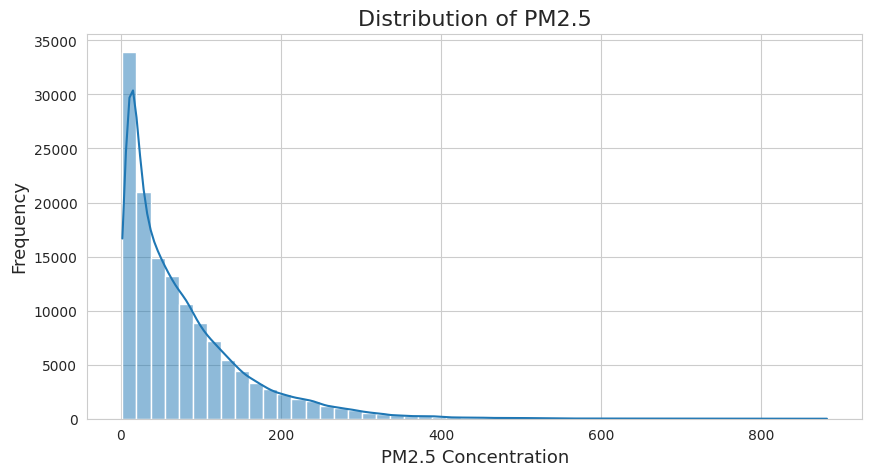

In [88]:
print("-" * 40)
print(" PM2.5 Distribution ")
print("-" * 40)

plt.figure(figsize=(10,5))

sns.histplot(
    df['PM2.5'],
    bins=50,
    kde=True
)

plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")

plt.show()

## Distribution of PM10

This section uses a histogram with a density curve to show the distribution of PM10 concentration levels in the dataset. A crucial measure of air quality, PM10 is particulate matter that is marginally larger than PM2.5.

Knowing the PM10 distribution makes it easier to determine how frequently various pollution levels occur as well as whether the data is skewed or contains extreme values. This study facilitates additional statistical and comparative research and offers significant insights into general patterns of air pollution.

----------------------------------------
 PM10 Distribution 
----------------------------------------


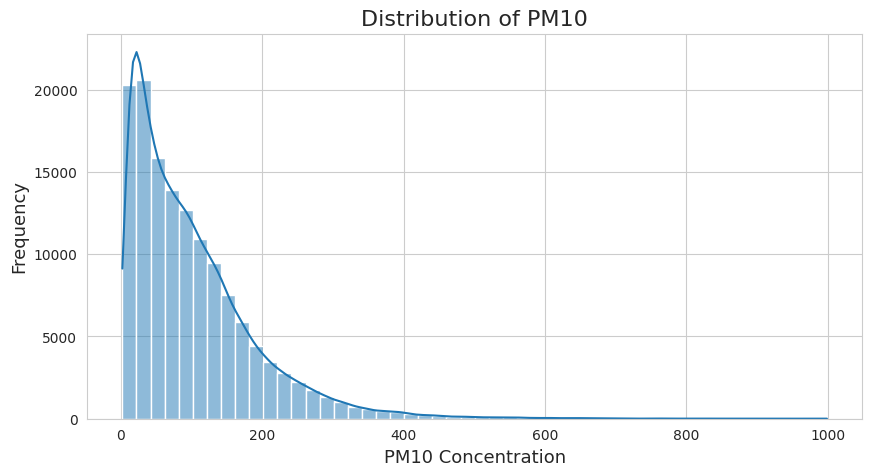

In [89]:
print("-" * 40)
print(" PM10 Distribution ")
print("-" * 40)

plt.figure(figsize=(10,5))

sns.histplot(
    df['PM10'],
    bins=50,
    kde=True
)

plt.title("Distribution of PM10")
plt.xlabel("PM10 Concentration")
plt.ylabel("Frequency")

plt.show()

## Distribution of Temperature

This section uses a histogram with a density curve to show how the temperature values in the dataset are distributed. One significant meteorological factor that can affect the concentrations of air pollutants and the general state of air quality is temperature.

We can determine frequent ranges, variability, and potentially extreme circumstances by examining the distribution to comprehend how temperature values change throughout the dataset. In later phases of the investigation, this aids in investigating correlations between pollution levels and weather conditions.

----------------------------------------
 Temperature Distribution 
----------------------------------------


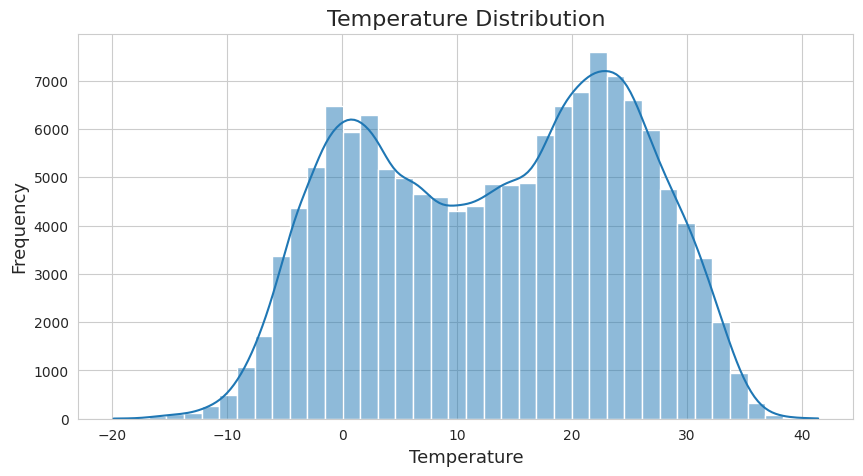

In [90]:
print("-" * 40)
print(" Temperature Distribution ")
print("-" * 40)

plt.figure(figsize=(10,5))

sns.histplot(
    df['TEMP'],
    bins=40,
    kde=True
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

## Boxplot for Pollutants

The distribution and spread of important air pollutants, such as PM2.5, PM10, SO2, NO2, CO, and O3, are shown in this section using a boxplot. Boxplots are helpful in determining each pollutant's central tendency, variability, and any outliers.

Extreme pollution occurrences or peculiar environmental conditions may be indicated by outliers in air quality data. Gaining insights into pollution intensity across many factors and identifying anomalies require an understanding of these patterns.

----------------------------------------
 Pollutant Boxplot 
----------------------------------------


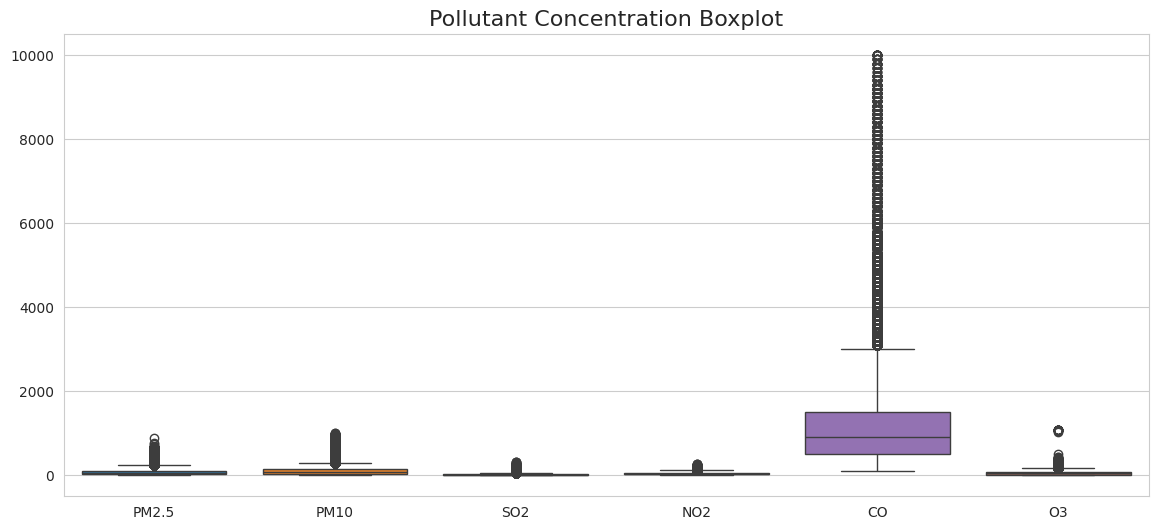

In [91]:
print("-" * 40)
print(" Pollutant Boxplot ")
print("-" * 40)

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

plt.figure(figsize=(14,6))

sns.boxplot(data=df[pollutants])

plt.title("Pollutant Concentration Boxplot")

plt.show()

## PM2.5 vs Temperature

This section uses a scatter plot to examine the relationship between temperature and PM2.5 concentration. The goal is to determine whether temperature variations have any discernible effects on air pollution levels.

This method of data visualisation allows us to spot trends, correlations, or clusters between the two variables, which aids in comprehending how weather patterns could affect air quality.

----------------------------------------
 PM2.5 vs Temperature 
----------------------------------------


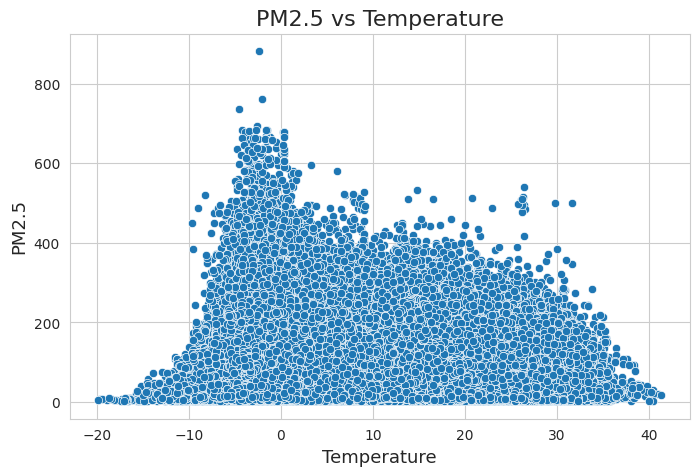

In [92]:
print("-" * 40)
print(" PM2.5 vs Temperature ")
print("-" * 40)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TEMP',
    y='PM2.5',
    data=df
)

plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")

plt.show()

## NO2 vs O3 Relationship

This section uses a scatter plot to illustrate the link between nitrogen dioxide (NO2) and ozone (O3). The objective is to investigate whether these two important air contaminants are correlated or interact in any way.

Because NO2 and O3 can affect one another through atmospheric chemical interactions, it is crucial to comprehend their relationship in air quality investigations. This analysis aids in finding any potential inverse linkages, dependencies, or trends between them.

----------------------------------------
 NO2 vs O3 
----------------------------------------


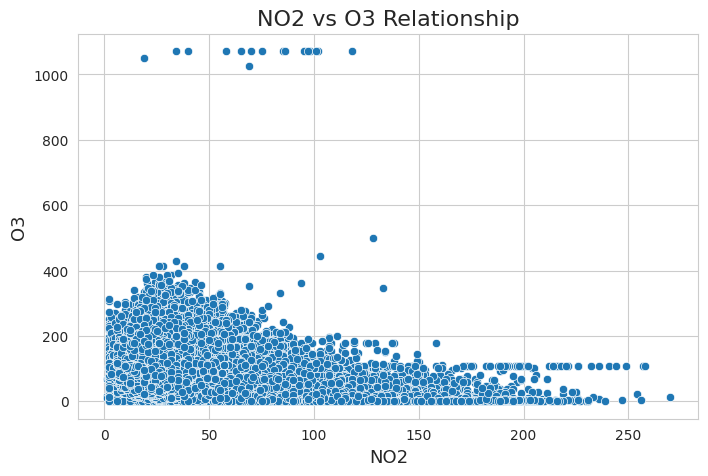

In [93]:
print("-" * 40)
print(" NO2 vs O3 ")
print("-" * 40)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='NO2',
    y='O3',
    data=df
)

plt.title("NO2 vs O3 Relationship")
plt.xlabel("NO2")
plt.ylabel("O3")

plt.show()

## Wind Speed vs PM2.5

This section uses a scatter plot to investigate the connection between PM2.5 concentration and wind speed. Understanding how wind conditions may affect the dispersion or buildup of tiny particulate particles in the air is the goal.

Because higher wind speeds can aid in the dispersal of pollutants and perhaps result in reduced PM2.5 concentrations, wind speed is a significant meteorological factor in air quality research. This study aids in determining whether the dataset has any other patterns, such as an inverse relationship.

----------------------------------------
 Wind Speed vs PM2.5 
----------------------------------------


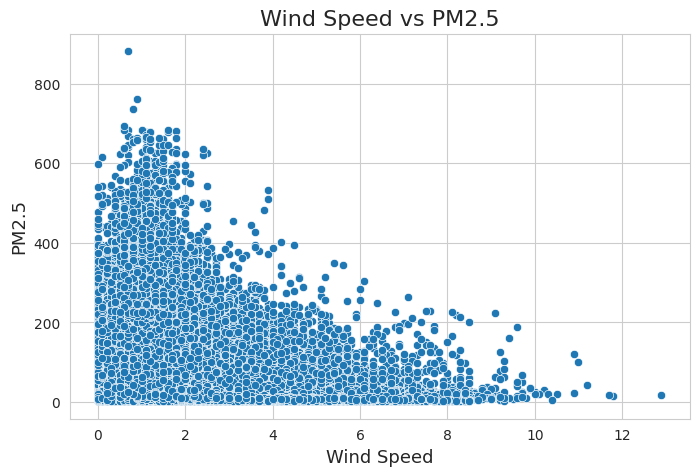

In [94]:
print("-" * 40)
print(" Wind Speed vs PM2.5 ")
print("-" * 40)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='WSPM',
    y='PM2.5',
    data=df
)

plt.title("Wind Speed vs PM2.5")
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")

plt.show()

## Monthly Average PM2.5 Trend

In order to comprehend how air pollution levels fluctuate throughout the year, this section examines the monthly average PM2.5 concentration. To find seasonal patterns and long-term trends, the data is grouped by month and the mean PM2.5 values are computed.

Because pollution levels frequently fluctuate due to seasonal weather, human activity, and environmental factors, it is crucial to comprehend monthly trends in air quality research. This graphic aids in the identification of times when pollution levels are higher or lower and facilitates a more accurate evaluation of changes in air quality over time.

----------------------------------------
 Monthly PM2.5 Trend 
----------------------------------------


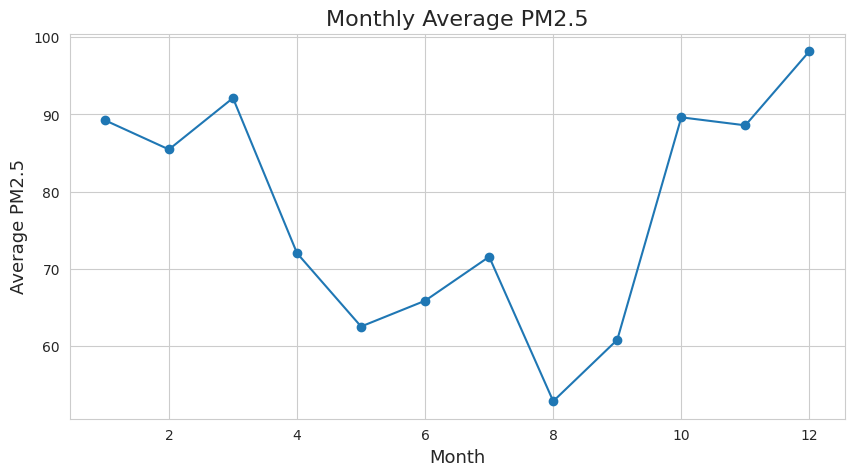

In [95]:
print("-" * 40)
print(" Monthly PM2.5 Trend ")
print("-" * 40)

monthly_pm25 = df.groupby('month')['PM2.5'].mean()

plt.figure(figsize=(10,5))

monthly_pm25.plot(marker='o')

plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")

plt.grid(True)

plt.show()

## Correlation Matrix

The dataset's correlation matrix, which displays the connections between each numerical variable, is shown in this section. The degree to which variables are positively or adversely correlated with one another can be ascertained through correlation analysis.

This is crucial for determining how contaminants and meteorological elements interact in air quality monitoring, such as how temperature, wind speed, or humidity may affect pollutant concentrations. By emphasising the most pertinent variables, strong correlations can also aid in the feature selection process for predictive modelling.

To facilitate visual interpretation of correlations, the results are presented using a gradient in the form of a heatmap.

In [96]:
print("-" * 40)
print(" Correlation Matrix ")
print("-" * 40)

correlation = df.corr(numeric_only=True)

correlation.style \
    .background_gradient(cmap='coolwarm') \
    .set_properties(**{
        'text-align': 'center'
    })

----------------------------------------
 Correlation Matrix 
----------------------------------------


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
No,1.000000,0.969533,0.043181,0.017764,0.000684,-0.026622,-0.032690,-0.244227,-0.030293,0.023048,-0.092072,-0.121019,0.183646,-0.097167,0.004293,0.055330
year,0.969533,1.000000,-0.202010,-0.005569,-0.000000,-0.027523,-0.025202,-0.189815,-0.041509,0.011540,-0.065862,-0.150598,0.181927,-0.160357,0.000466,0.087052
month,0.043181,-0.202010,1.000000,0.010522,-0.000000,0.005194,-0.030067,-0.203431,0.047756,0.044796,-0.099217,0.132047,-0.012119,0.266770,0.015663,-0.133132
day,0.017764,-0.005569,0.010522,1.000000,0.000000,0.002354,0.023630,-0.005206,0.001192,-0.015589,0.002041,0.014072,0.023143,0.023572,-0.001891,-0.014356
hour,0.000684,-0.000000,-0.000000,0.000000,1.000000,0.018650,0.060939,0.023770,0.006826,-0.019273,0.274736,0.143540,-0.038635,-0.012025,0.013681,0.139915
PM2.5,-0.026622,-0.027523,0.005194,0.002354,0.018650,1.000000,0.884934,0.488840,0.669935,0.792427,-0.114211,-0.111971,0.018005,0.125085,-0.012805,-0.267374
PM10,-0.032690,-0.025202,-0.030067,0.023630,0.060939,0.884934,1.000000,0.457589,0.640764,0.706722,-0.072761,-0.080240,-0.014785,0.075591,-0.022386,-0.161516
SO2,-0.244227,-0.189815,-0.203431,-0.005206,0.023770,0.488840,0.457589,1.000000,0.516008,0.537641,-0.151850,-0.313548,0.232689,-0.259221,-0.039832,-0.121737
NO2,-0.030293,-0.041509,0.047756,0.001192,0.006826,0.669935,0.640764,0.516008,1.000000,0.716675,-0.438795,-0.287747,0.213815,-0.056309,-0.043213,-0.370905
CO,0.023048,0.011540,0.044796,-0.015589,-0.019273,0.792427,0.706722,0.537641,0.716675,1.000000,-0.291549,-0.303675,0.181715,-0.041391,-0.011063,-0.294017


## Correlation Heatmap

In order to make the correlations between numerical variables easier to understand, this part uses a heatmap to visualise the correlation matrix. The heatmap makes it simpler to understand trends in the dataset by highlighting both strong and weak relationships using colour intensity.

This graphic is crucial for air quality analysis since it makes it easier to see how various pollutants and meteorological conditions interact. By highlighting the variables that are highly correlated and could affect the results of predictive modelling, it also aids in feature selection.

----------------------------------------
 Correlation Heatmap 
----------------------------------------


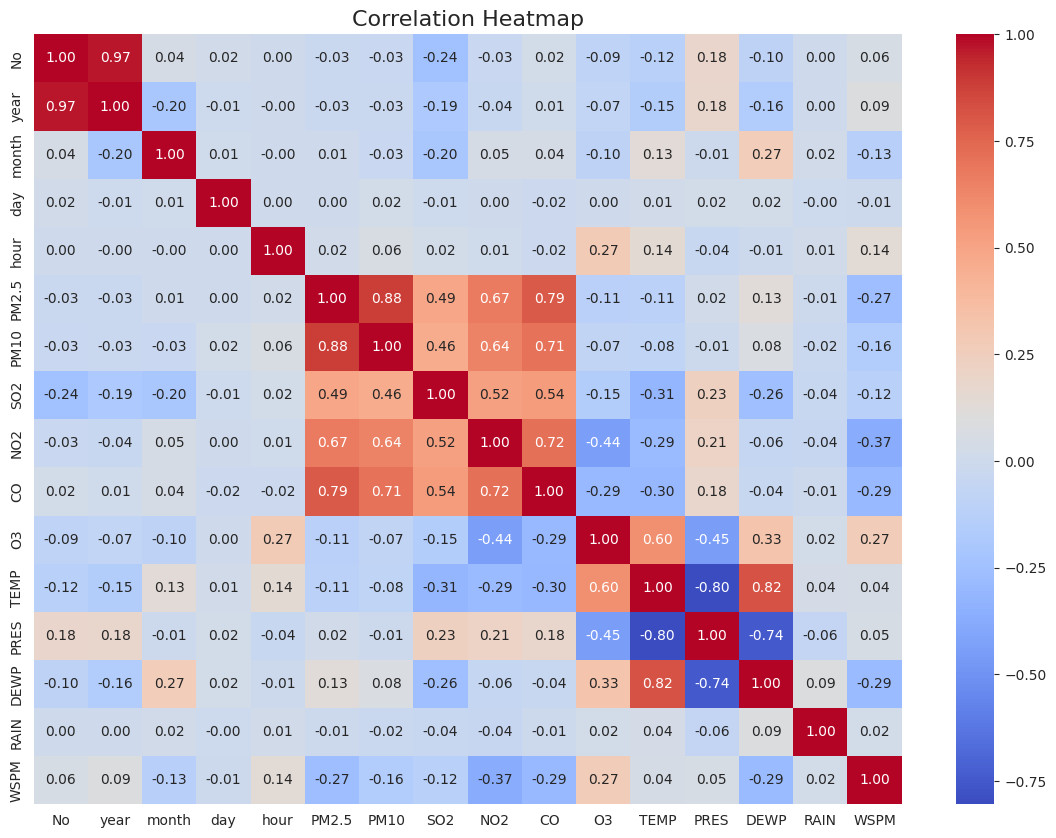

In [97]:
print("-" * 40)
print(" Correlation Heatmap ")
print("-" * 40)

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

## Pairplot Analysis

The pairwise connections between a few of the dataset's important variables—PM2.5, PM10, SO2, NO2, and temperature—are shown in this section using a pairplot. In addition to displaying the distribution of each individual characteristic, a pairplot aids in comprehending how each variable interacts with others through scatter plots.

Because it makes it easy to quickly identify correlations, clusters, and potential nonlinear interactions between contaminants and meteorological parameters, this is helpful in the analysis of air quality. Additionally, it aids in identifying patterns that would not be apparent using correlation matrices or single-variable analysis alone.

----------------------------------------
 Pairplot Analysis 
----------------------------------------


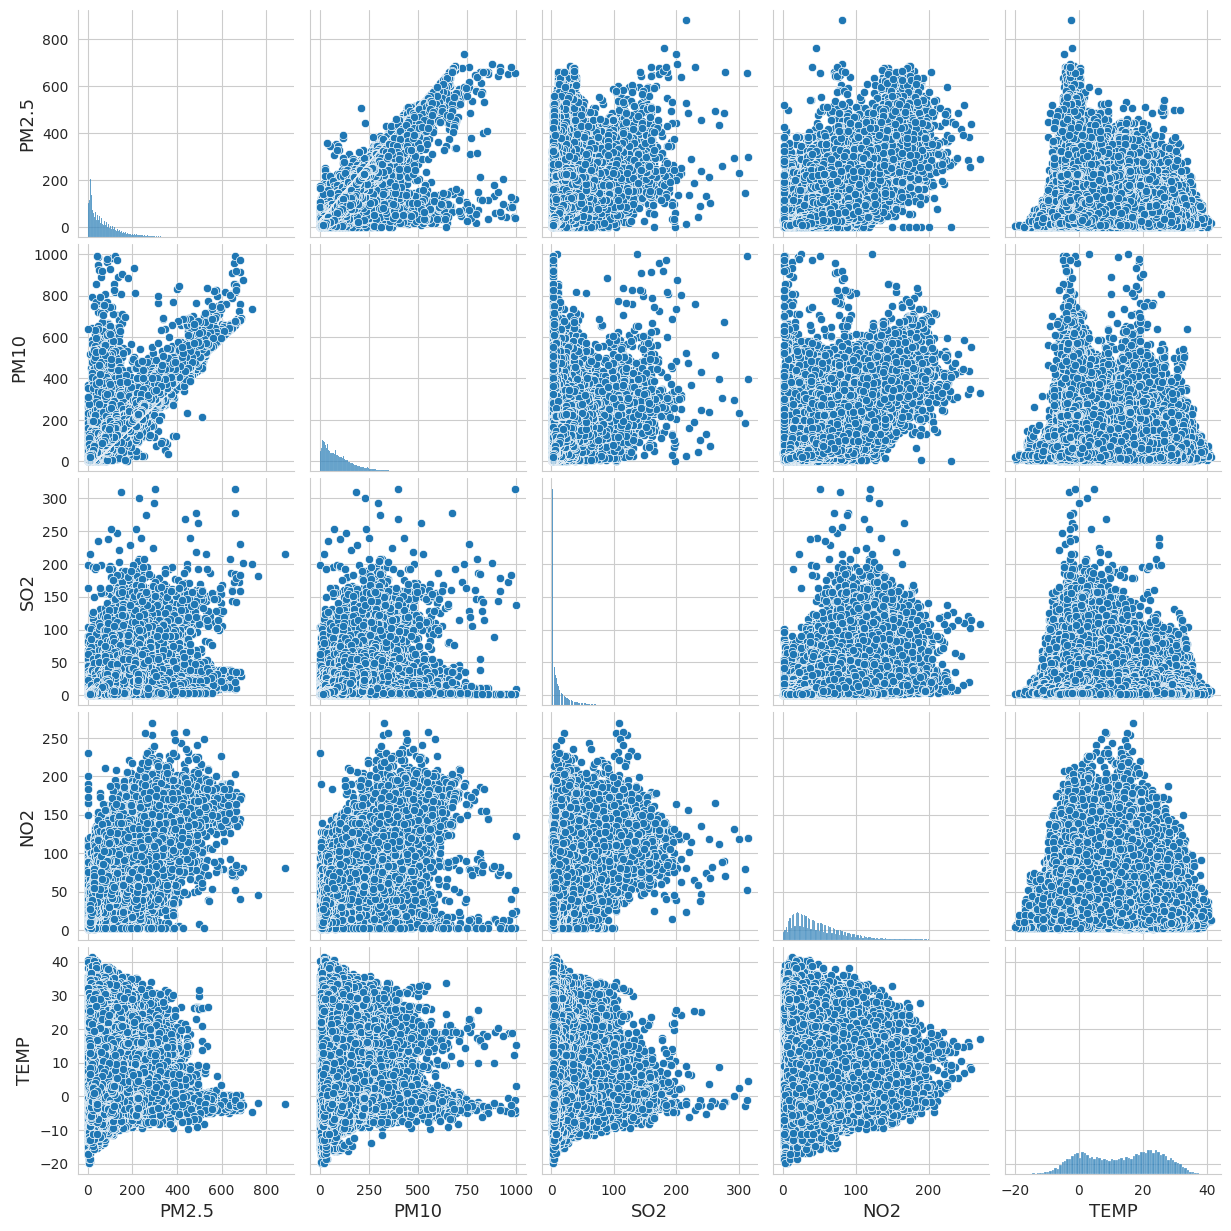

In [98]:
print("-" * 40)
print(" Pairplot Analysis ")
print("-" * 40)

selected_features = [
    'PM2.5',
    'PM10',
    'SO2',
    'NO2',
    'TEMP'
]

sns.pairplot(df[selected_features])

plt.show()

## AQI Level Count Plot

This section uses a countplot to show the distribution of AQI levels. Based on PM2.5 concentration, it displays the frequency of each air quality category (Good, Moderate, Unhealthy, etc.) in the dataset.

Because it offers a clear knowledge of the general air quality conditions reported in the dataset, this analysis is significant. It aids in determining whether cleaner or more polluted air conditions predominate in the dataset, which is helpful for interpretation and upcoming modelling tasks.

----------------------------------------
 AQI Level Countplot 
----------------------------------------


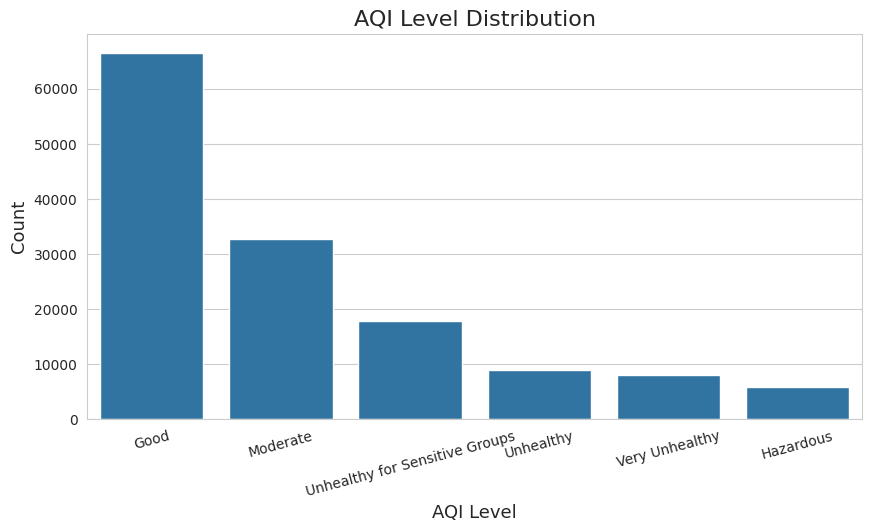

In [99]:
print("-" * 40)
print(" AQI Level Countplot ")
print("-" * 40)

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='AQI_Level',
    order=df['AQI_Level'].value_counts().index
)

plt.title("AQI Level Distribution")
plt.xlabel("AQI Level")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

## Station-wise PM2.5 Comparison

This section uses a bar chart to examine the average PM2.5 concentration across various monitoring sites. To compare pollution levels across places, the data is sorted and grouped by station.

Due to variables like traffic intensity, industrial activity, and local environmental conditions, air quality can differ greatly between different geographic locations, which makes this examination crucial. Recognising station-specific variations facilitates location-based environmental assessment and the identification of high-risk pollution zones.

----------------------------------------
 Station-wise PM2.5 
----------------------------------------


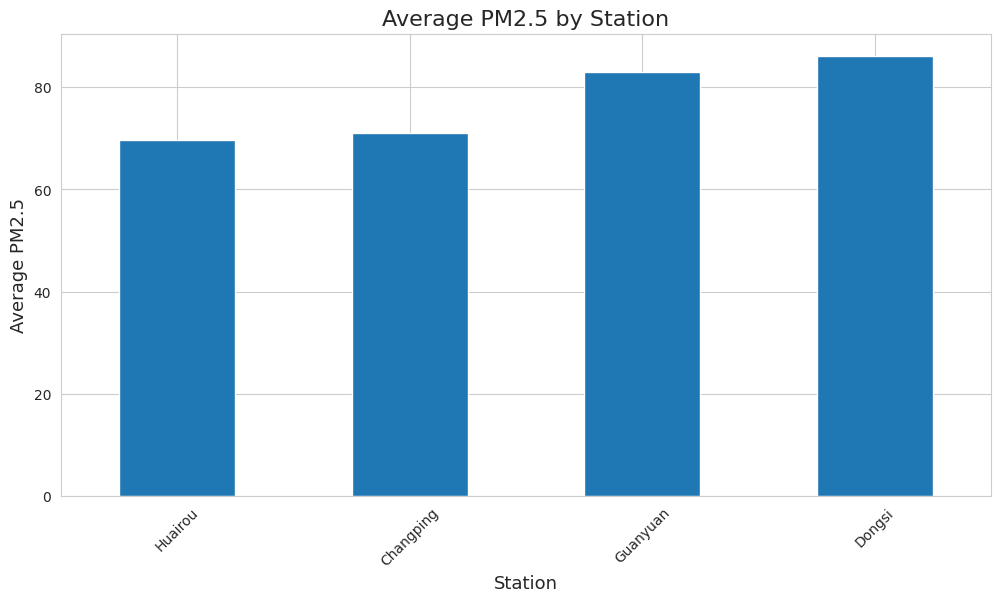

In [100]:
print("-" * 40)
print(" Station-wise PM2.5 ")
print("-" * 40)

station_pm25 = df.groupby('station')['PM2.5'].mean().sort_values()

plt.figure(figsize=(12,6))

station_pm25.plot(kind='bar')

plt.title("Average PM2.5 by Station")
plt.xlabel("Station")
plt.ylabel("Average PM2.5")

plt.xticks(rotation=45)

plt.show()

## Time Series Analysis

This section uses a time series plot to show the average PM2.5 concentration trend over time. To see how air pollution levels vary over time, the data is categorised by datetime.

Because it makes it easier to spot temporal patterns like seasonal changes, long-term trends, and abrupt pollution spikes, time series analysis is crucial to research on air quality. This facilitates future forecasting and decision-making and enables a deeper comprehension of how air quality changes over time.

----------------------------------------
 Time Series Plot 
----------------------------------------


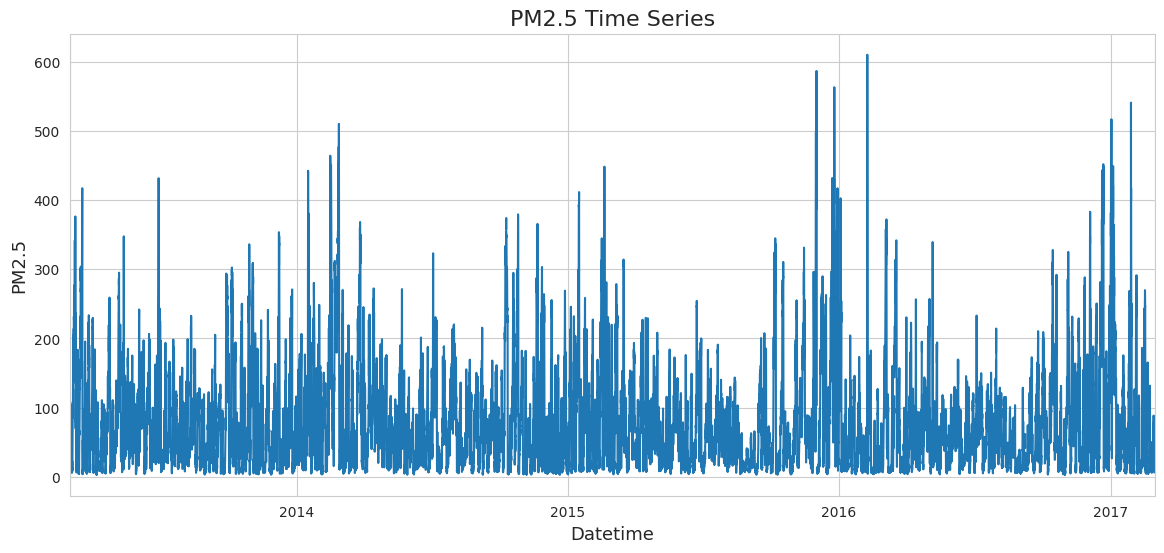

In [101]:
print("-" * 40)
print(" Time Series Plot ")
print("-" * 40)

daily_pm25 = df.groupby('datetime')['PM2.5'].mean()

plt.figure(figsize=(14,6))

daily_pm25.plot()

plt.title("PM2.5 Time Series")
plt.xlabel("Datetime")
plt.ylabel("PM2.5")

plt.show()

## Violin Plot — Pollutant Distribution

The distribution of important air pollutants, such as PM2.5, PM10, SO2, NO2, CO, and O3, is shown in this section using a violin plot. The characteristics of a boxplot and a density plot are combined in a violin plot, which displays the data's probability distribution as well as its spread.

This aids in comprehending the structure of the distributions of pollutants as well as their central tendency and variability. Skewness, multimodal patterns, and extreme values in air quality data can be found with its help.

----------------------------------------
 Violin Plot 
----------------------------------------


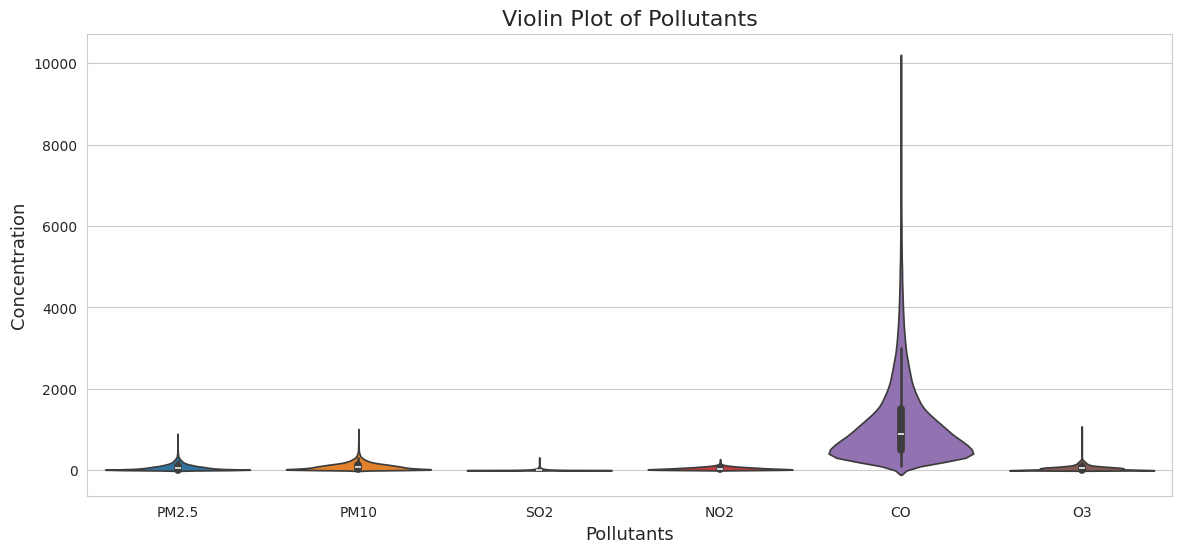

In [102]:
print("-" * 40)
print(" Violin Plot ")
print("-" * 40)

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

plt.figure(figsize=(14,6))

sns.violinplot(data=df[pollutants])

plt.title("Violin Plot of Pollutants")
plt.xlabel("Pollutants")
plt.ylabel("Concentration")

plt.show()

## KDE Plot — Pollutant Density Distribution

This section uses a Kernel Density Estimation (KDE) plot to show the PM2.5 concentration distribution. A KDE plot, as contrast to a histogram, shows the probability density of the data as a smooth curve.

This aids in comprehending the peaks, skewness, and concentration areas of the underlying PM2.5 level distribution pattern. It is helpful in determining the distribution of air pollution values in a more continuous and comprehensible manner.

----------------------------------------
 KDE Plot 
----------------------------------------


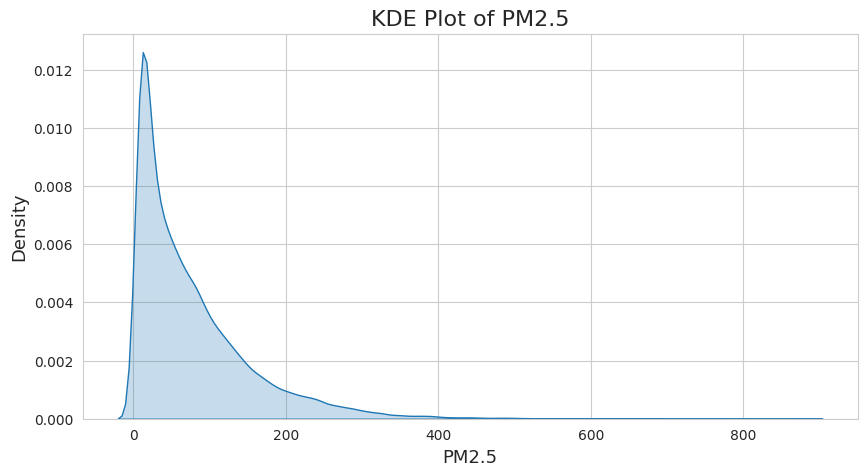

In [103]:
print("-" * 40)
print(" KDE Plot ")
print("-" * 40)

plt.figure(figsize=(10,5))

sns.kdeplot(df['PM2.5'], fill=True)

plt.title("KDE Plot of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Density")

plt.show()

## Seasonal Heatmap

This section uses a heatmap to show the average PM2.5 concentration over several months and seasons. To compare how air pollution changes over time in a more thorough and organised manner, the data is organised into a pivot table.

By illustrating how PM2.5 levels fluctuate throughout the year, this research aids in the identification of seasonal pollution trends. It is helpful for identifying times when pollution levels are higher or lower and for comprehending how seasonal elements affect changes in air quality.

----------------------------------------
 Seasonal Heatmap 
----------------------------------------


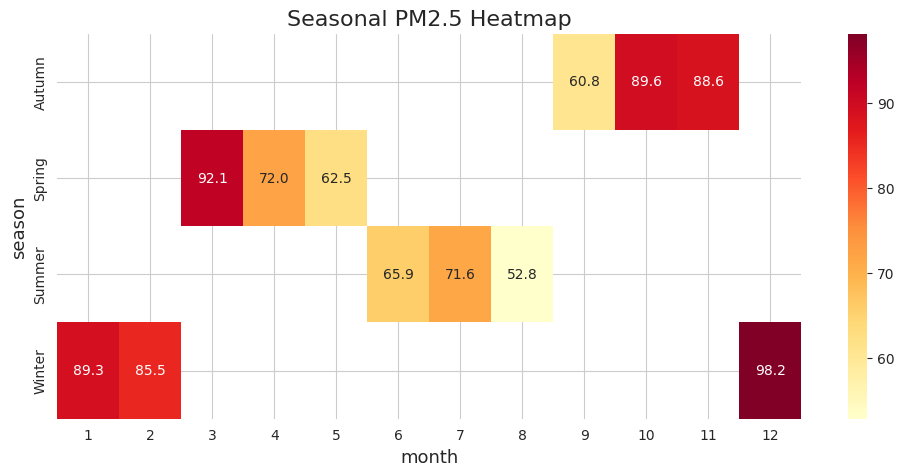

In [104]:
print("-" * 40)
print(" Seasonal Heatmap ")
print("-" * 40)

seasonal_data = df.pivot_table(
    values='PM2.5',
    index='season',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(12,5))

sns.heatmap(
    seasonal_data,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f'
)

plt.title("Seasonal PM2.5 Heatmap")

plt.show()

## Hourly Pollution Trends

This section uses a line plot to show the average PM2.5 concentration at various times of the day. To comprehend how air pollution levels change over the course of a 24-hour cycle, the data is categorised by hour.

Because human activities like traffic emissions and industrial operations frequently cause fluctuations in air quality throughout the day, this analysis is crucial. Finding hourly trends facilitates time-based environmental study and aids in comprehending peak pollution periods.



----------------------------------------
 Hourly PM2.5 Trend 
----------------------------------------


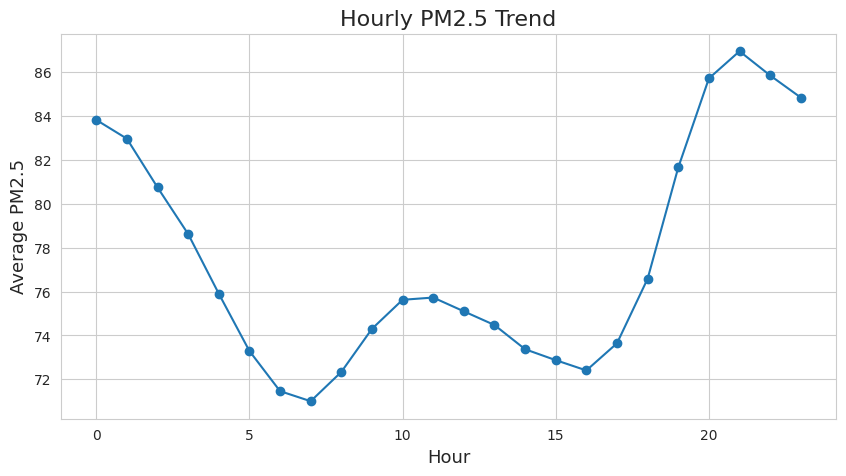

In [105]:
print("-" * 40)
print(" Hourly PM2.5 Trend ")
print("-" * 40)

hourly_pm25 = df.groupby('hour')['PM2.5'].mean()

plt.figure(figsize=(10,5))

hourly_pm25.plot(marker='o')

plt.title("Hourly PM2.5 Trend")
plt.xlabel("Hour")
plt.ylabel("Average PM2.5")

plt.grid(True)

plt.show()

## Rainfall vs Pollution Analysis

This section uses a scatter plot to examine the connection between PM2.5 concentration and rainfall. The goal is to determine whether rainfall affects air pollution levels in any way.

By assisting in the removal of airborne particles, rainfall can improve the quality of the air by lowering PM2.5 concentrations during or after precipitation episodes. This visualisation facilitates additional environmental interpretation of pollution behaviour under various weather circumstances and assists in determining whether such a pattern exists in the dataset.

----------------------------------------
 Rainfall vs PM2.5 
----------------------------------------


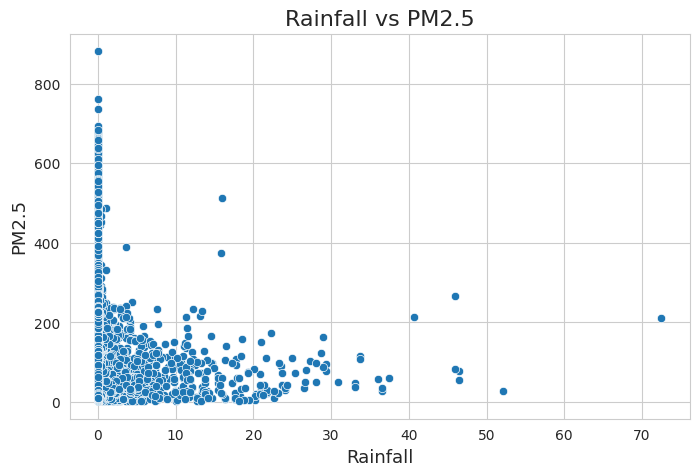

In [106]:
print("-" * 40)
print(" Rainfall vs PM2.5 ")
print("-" * 40)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='RAIN',
    y='PM2.5',
    data=df
)

plt.title("Rainfall vs PM2.5")
plt.xlabel("Rainfall")
plt.ylabel("PM2.5")

plt.show()

## AQI Level Pie Chart

This section uses a pie chart to show the percentage of various AQI levels. It shows the distribution of the dataset according to PM2.5 levels across different categories of air quality.

To comprehend the proportion contribution of each AQI category in the dataset, a pie chart can be helpful. This offers a clear summary of the overall distribution of pollution in an easy-to-understand style and aids in rapidly identifying the most prevalent air quality conditions.

----------------------------------------
 AQI Pie Chart 
----------------------------------------


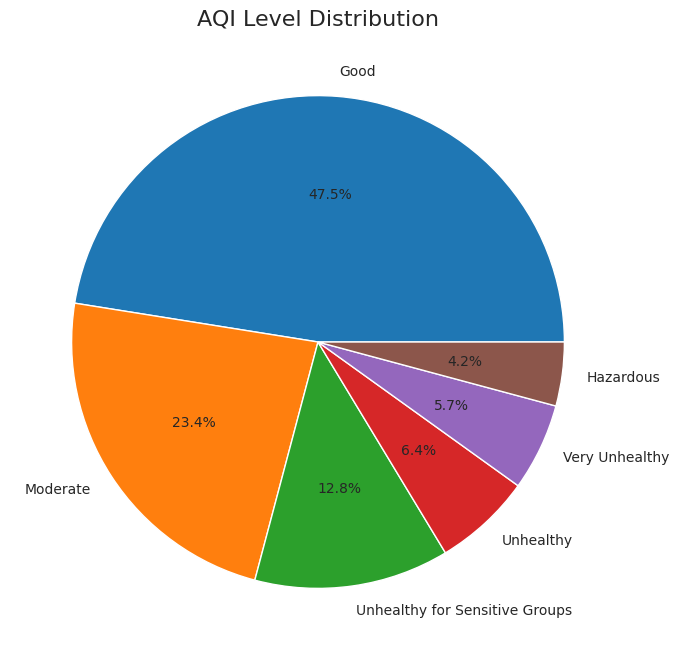

In [107]:
print("-" * 40)
print(" AQI Pie Chart ")
print("-" * 40)

aqi_counts = df['AQI_Level'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    aqi_counts,
    labels=aqi_counts.index,
    autopct='%1.1f%%'
)

plt.title("AQI Level Distribution")

plt.show()

## Wind Direction Analysis

This section uses a countplot to show the frequency of various wind directions. Knowing how frequently winds blow from each direction in the dataset is helpful.

Because wind direction affects the movement and dispersion of pollutants, it is a significant meteorological factor in studies of air quality. This investigation sheds light on the dominant wind patterns, which might aid in comprehending the movement and buildup of pollutants in various locations.

----------------------------------------
 Wind Direction Analysis 
----------------------------------------


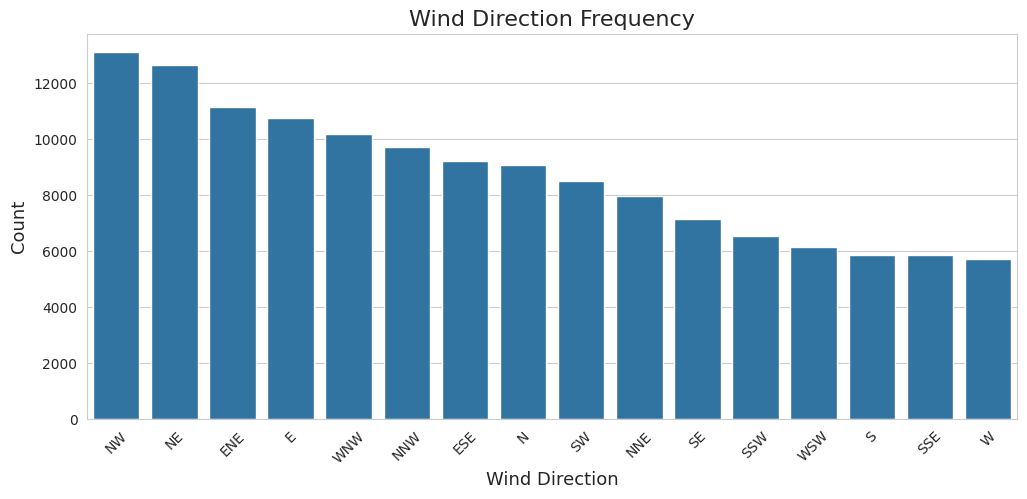

In [108]:
print("-" * 40)
print(" Wind Direction Analysis ")
print("-" * 40)

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='wd',
    order=df['wd'].value_counts().index
)

plt.title("Wind Direction Frequency")
plt.xlabel("Wind Direction")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Rolling Average Trend Line

The 24-hour rolling average of PM2.5 concentration over time is shown in this section. Short-term variations in the data are smoothed out by the rolling mean, which also makes the general trend easier to see.

This method is crucial for analysing air quality because pollution levels can fluctuate quickly. We can lessen noise in the data and gain a better understanding of long-term mobility, trends, and persistent pollution patterns over time by using a rolling average.

----------------------------------------
 Rolling Average Trend 
----------------------------------------


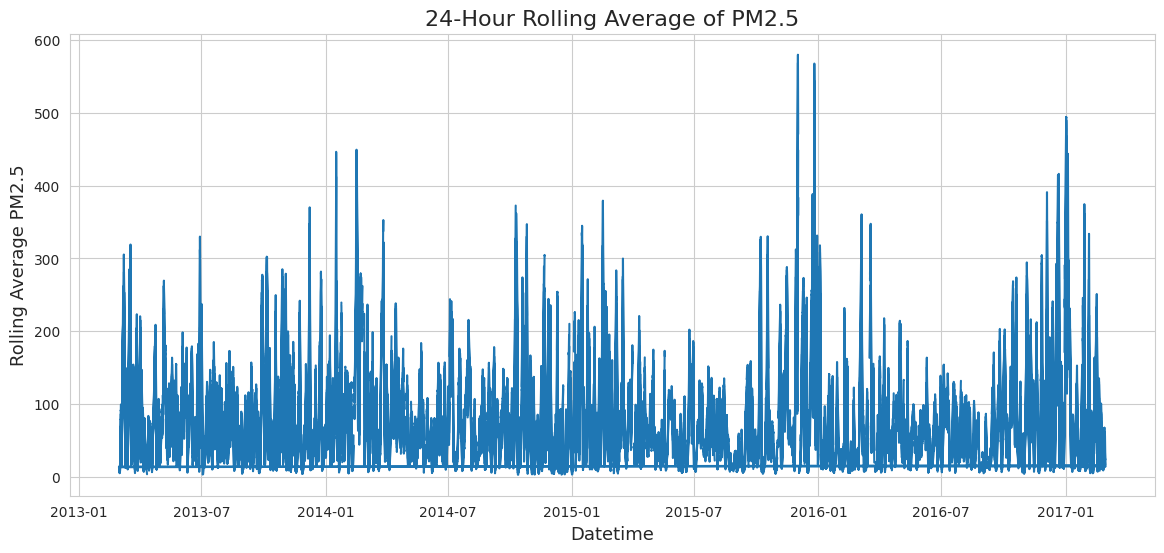

In [109]:
print("-" * 40)
print(" Rolling Average Trend ")
print("-" * 40)

rolling_pm25 = df['PM2.5'].rolling(window=24).mean()

plt.figure(figsize=(14,6))

plt.plot(
    df['datetime'],
    rolling_pm25
)

plt.title("24-Hour Rolling Average of PM2.5")
plt.xlabel("Datetime")
plt.ylabel("Rolling Average PM2.5")

plt.show()

## Summary

In order to derive significant insights, this section concentrated on analysing the cleaned air quality dataset using statistical approaches and visualisation tools. Pollutant distributions, boxplots for outlier detection, and scatter plots to examine correlations between air quality measures and meteorological elements including temperature, wind speed, and rainfall were just a few of the many plots and analyses that were employed.

To comprehend how pollution levels vary over time, time-based studies such hourly and monthly trends, rolling averages, and seasonal heatmaps were employed. While AQI categorisation visualisations offered a clearer understanding of overall air quality conditions, correlation analysis and pairplots assisted in identifying correlations between variables.

Overall, by identifying patterns, trends, and relationships that are crucial for more in-depth analysis and upcoming predictive modelling, this step converted raw cleansed data into actionable insights.

## Task 3: Model Building

Using the cleaned and processed air quality dataset, a machine learning model is developed in this part. The emphasis switches to preparing the data for modelling by using best practices including feature scaling, encoding categorical variables, and choosing the most pertinent features when data pretreatment and exploratory analysis are finished.

The model is then trained using the prepared dataset after an appropriate algorithm is selected based on the problem's characteristics. Additionally, hyperparameter adjustment can be used to guarantee improved generalisation and enhance performance.

Lastly, the model's accuracy, dependability, and predictive power are assessed using suitable performance indicators. In order to guarantee that the final model is both efficient and comprehensible for air quality prediction, the modelling choices are supported by data characteristics and evaluation findings.

##3.1 Problem Definition

Particularly in urban and industrial areas, air pollution has grown to be a serious environmental and public health concern. Because PM2.5 is a continuous target variable, this is a supervised learning regression problem. (fine particulate matter with a diameter of less than 2.5 micrometres) can penetrate deeply into the lungs and bloodstream and cause serious health problems like respiratory and cardiovascular diseases, it is one of the most important indicators of air quality among various pollutants.

Predicting PM2.5 concentration levels based on meteorological circumstances and other air pollutant factors including temperature, humidity, wind speed, NO₂, SO₂, CO, and O₃ levels is the goal of this machine learning model-building challenge.

Our goal is to comprehend the connection between PM2.5 fluctuation and environmental factors by creating a predictive model. In addition to supporting environmental monitoring, early warning systems, and data-driven policy decisions, this aids in identifying the main causes of air pollution.

In order to create a regression model that can precisely estimate PM2.5 levels using historical data, machine learning techniques must be applied. Appropriate measures like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R2 Score will be used to assess the model's performance.

 # Install & Import Libraries

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

 # Load Dataset

In [111]:
df = pd.read_csv("/content/cleaned_air_quality_dataset.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,day_name,month_name,season,AQI_Level
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,89.000000,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00,Friday,March,Spring,Good
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,88.000000,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00,Friday,March,Spring,Good
2,3,2013,3,1,2,7.0,7.0,15.811354,17.000000,300.000000,60.000000,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00,Friday,March,Spring,Good
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1192.068962,57.692177,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00,Friday,March,Spring,Good
4,5,2013,3,1,4,3.0,3.0,7.000000,47.129503,200.000000,84.000000,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00,Friday,March,Spring,Good


In [112]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(140256, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   No          140256 non-null  int64  
 1   year        140256 non-null  int64  
 2   month       140256 non-null  int64  
 3   day         140256 non-null  int64  
 4   hour        140256 non-null  int64  
 5   PM2.5       140256 non-null  float64
 6   PM10        140256 non-null  float64
 7   SO2         140256 non-null  float64
 8   NO2         140256 non-null  float64
 9   CO          140256 non-null  float64
 10  O3          140256 non-null  float64
 11  TEMP        140256 non-null  float64
 12  PRES        140256 non-null  float64
 13  DEWP        140256 non-null  float64
 14  RAIN        140256 non-null  float64
 15  wd          139655 non-null  object 
 16  WSPM        140256 non-null  float64
 17  station     140256 non-null  object 
 18  datetime    140256 non-null  ob

# Define Features & Target

In [113]:
target_column = 'PM2.5'

X = df.drop(target_column, axis=1)
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (140256, 22)
y shape: (140256,)


## Train-Test Split

In [114]:
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas if not already imported globally

# Re-load df and define X, y to make this cell self-contained
df = pd.read_csv("/content/cleaned_air_quality_dataset.csv")
target_column = 'PM2.5'
X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

In [115]:
from sklearn.preprocessing import StandardScaler
import numpy as np # Ensure numpy is imported

scaler = StandardScaler()

# Select only numerical columns for scaling
numeric_cols_train = X_train.select_dtypes(include=np.number).columns
X_train = scaler.fit_transform(X_train[numeric_cols_train])

numeric_cols_test = X_test.select_dtypes(include=np.number).columns
X_test = scaler.transform(X_test[numeric_cols_test])

In [116]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

 # Data Understanding

In [117]:
# Dataset shape summary (stylish)
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})

shape_df.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
}).background_gradient(cmap='Blues')

,Metric,Value
0,Rows,140256
1,Columns,23


In [118]:
df.describe().T.style \
    .background_gradient(cmap='coolwarm') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    }) \
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#2c3e50'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center')
            ]
        }
    ])

,count,mean,std,min,25%,50%,75%,max
No,140256.000000,17532.500000,10122.141000,1.000000,8766.750000,17532.500000,26298.250000,35064.000000
year,140256.000000,2014.662560,1.177201,2013.000000,2014.000000,2015.000000,2016.000000,2017.000000
month,140256.000000,6.522930,3.448715,1.000000,4.000000,7.000000,10.000000,12.000000
day,140256.000000,15.729637,8.800123,1.000000,8.000000,16.000000,23.000000,31.000000
hour,140256.000000,11.500000,6.922211,0.000000,5.750000,11.500000,17.250000,23.000000
PM2.5,140256.000000,77.481501,77.497957,2.000000,20.000000,55.000000,106.000000,882.000000
PM10,140256.000000,101.399508,89.001024,2.000000,35.000000,81.000000,139.000000,999.000000
SO2,140256.000000,15.811354,21.608348,0.285600,2.000000,7.000000,19.000000,315.000000
NO2,140256.000000,47.129503,32.420124,1.026500,22.000000,41.000000,64.000000,270.000000
CO,140256.000000,1192.068962,1068.882395,100.000000,500.000000,900.000000,1400.000000,10000.000000


In [119]:
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2).values
})

missing_df.sort_values("Missing Values", ascending=False).style \
    .background_gradient(cmap='Reds') \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    })

,Column,Missing Values,Missing %
15,wd,601,0.430000
1,year,0,0.000000
0,No,0,0.000000
3,day,0,0.000000
4,hour,0,0.000000
5,PM2.5,0,0.000000
2,month,0,0.000000
6,PM10,0,0.000000
7,SO2,0,0.000000
9,CO,0,0.000000


In [120]:
print("New Dataset Shape:", df.shape)
df.head().style.background_gradient(cmap='Blues')

New Dataset Shape: (140256, 23)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,day_name,month_name,season,AQI_Level
0,1,2013,3,1,0,9.000000,9.000000,3.000000,17.000000,300.000000,89.000000,-0.500000,1024.500000,-21.400000,0.000000,NNW,5.700000,Dongsi,2013-03-01 00:00:00,Friday,March,Spring,Good
1,2,2013,3,1,1,4.000000,4.000000,3.000000,16.000000,300.000000,88.000000,-0.700000,1025.100000,-22.100000,0.000000,NW,3.900000,Dongsi,2013-03-01 01:00:00,Friday,March,Spring,Good
2,3,2013,3,1,2,7.000000,7.000000,15.811354,17.000000,300.000000,60.000000,-1.200000,1025.300000,-24.600000,0.000000,NNW,5.300000,Dongsi,2013-03-01 02:00:00,Friday,March,Spring,Good
3,4,2013,3,1,3,3.000000,3.000000,5.000000,18.000000,1192.068962,57.692177,-1.400000,1026.200000,-25.500000,0.000000,N,4.900000,Dongsi,2013-03-01 03:00:00,Friday,March,Spring,Good
4,5,2013,3,1,4,3.000000,3.000000,7.000000,47.129503,200.000000,84.000000,-1.900000,1027.100000,-24.500000,0.000000,NNW,3.200000,Dongsi,2013-03-01 04:00:00,Friday,March,Spring,Good


In [121]:
import pandas as pd
df = pd.read_csv("/content/cleaned_air_quality_dataset.csv")
target_column = 'PM2.5'   # target variable (what we want to predict)

# Features (input variables)
X = df.drop(target_column, axis=1)

# Target (output variable)
y = df[target_column]

print("Shape of X (Features):", X.shape)
print("Shape of y (Target):", y.shape)

print("\nFirst 5 rows of Features (X):")
display(X.head().style.background_gradient(cmap='Blues'))

Shape of X (Features): (140256, 22)
Shape of y (Target): (140256,)

First 5 rows of Features (X):


,No,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,day_name,month_name,season,AQI_Level
0,1,2013,3,1,0,9.000000,3.000000,17.000000,300.000000,89.000000,-0.500000,1024.500000,-21.400000,0.000000,NNW,5.700000,Dongsi,2013-03-01 00:00:00,Friday,March,Spring,Good
1,2,2013,3,1,1,4.000000,3.000000,16.000000,300.000000,88.000000,-0.700000,1025.100000,-22.100000,0.000000,NW,3.900000,Dongsi,2013-03-01 01:00:00,Friday,March,Spring,Good
2,3,2013,3,1,2,7.000000,15.811354,17.000000,300.000000,60.000000,-1.200000,1025.300000,-24.600000,0.000000,NNW,5.300000,Dongsi,2013-03-01 02:00:00,Friday,March,Spring,Good
3,4,2013,3,1,3,3.000000,5.000000,18.000000,1192.068962,57.692177,-1.400000,1026.200000,-25.500000,0.000000,N,4.900000,Dongsi,2013-03-01 03:00:00,Friday,March,Spring,Good
4,5,2013,3,1,4,3.000000,7.000000,47.129503,200.000000,84.000000,-1.900000,1027.100000,-24.500000,0.000000,NNW,3.200000,Dongsi,2013-03-01 04:00:00,Friday,March,Spring,Good


In [122]:
from sklearn.preprocessing import StandardScaler
import pandas as pd # Ensure pandas is imported if not already globally accessible
import numpy as np # Ensure numpy is imported if not already globally accessible

scaler = StandardScaler()

# Select only numerical columns from X for scaling
numeric_cols = X.select_dtypes(include=np.number).columns
X_numeric = X[numeric_cols]

X_scaled = scaler.fit_transform(X_numeric)

print("Shape of Scaled Data:", X_scaled.shape)

scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
display(scaled_df.head().style.background_gradient(cmap='viridis'))

Shape of Scaled Data: (140256, 15)


,No,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,-1.732001,-1.412304,-1.021523,-1.673805,-1.661325,-1.038188,-0.592891,-0.929349,-0.834584,0.564956,-1.204065,1.390116,-1.713434,-0.078584,3.139923
1,-1.731903,-1.412304,-1.021523,-1.673805,-1.516862,-1.094368,-0.592891,-0.960194,-0.834584,0.546910,-1.221456,1.447398,-1.763980,-0.078584,1.702231
2,-1.731804,-1.412304,-1.021523,-1.673805,-1.372399,-1.060660,-0.000000,-0.929349,-0.834584,0.041645,-1.264933,1.466492,-1.944502,-0.078584,2.820436
3,-1.731705,-1.412304,-1.021523,-1.673805,-1.227936,-1.105604,-0.500334,-0.898504,0.000000,0.000000,-1.282324,1.552416,-2.009489,-0.078584,2.500949
4,-1.731606,-1.412304,-1.021523,-1.673805,-1.083473,-1.105604,-0.407777,-0.000000,-0.928140,0.474730,-1.325802,1.638339,-1.937281,-0.078584,1.143128


In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Training Set Shape (X_train):", X_train.shape)
print("Testing Set Shape (X_test):", X_test.shape)
print("Training Target Shape (y_train):", y_train.shape)
print("Testing Target Shape (y_test):", y_test.shape)

Training Set Shape (X_train): (112204, 15)
Testing Set Shape (X_test): (28052, 15)
Training Target Shape (y_train): (112204,)
Testing Target Shape (y_test): (28052,)


In [124]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Model Training Completed Successfully!")

print("\nFirst 10 Predictions:")
print(lr_pred[:10])

Model Training Completed Successfully!

First 10 Predictions:
[ 36.57506232 279.03380485  33.9196539  173.55007671   8.86706295
  16.13636238  93.24674568  25.80806751  92.24408475 221.27046018]


## Task 4: Application Development

In [125]:
!git clone https://github.com/SI-GRush34/beijing-air-quality-project


Cloning into 'beijing-air-quality-project'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 30 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 4.66 MiB | 6.00 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [126]:
%cd beijing-air-quality-project

/content/beijing-air-quality-project/beijing-air-quality-project


In [127]:
!ls

Beijing-Air-Quality-Project.ipynb
PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
README.md
Task1_Data_Selection_and_Handling.ipynb


In [128]:
!touch app.py

In [129]:
!pip install streamlit -q
!pip install pyngrok -q
!pip install plotly -q
!pip install streamlit-option-menu -q

In [130]:
!pip install pandas numpy scikit-learn plotly streamlit -q

In [131]:
%cd /content/beijing-air-quality-project

/content/beijing-air-quality-project


In [132]:
!git config --global user.name "SI-GRush34"
!git config --global user.email "rashmysud97@gmail.com"

In [133]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# =========================
# PAGE CONFIG
# =========================
st.set_page_config(
    page_title="Air Quality Dashboard",
    layout="wide"
)

# =========================
# TITLE
# =========================
st.title("🌍 Air Quality Analysis & Prediction Dashboard")
st.markdown("Analyze pollution trends and predict PM2.5 levels using Machine Learning.")

# =========================
# LOAD DATA
# =========================
@st.cache_data
def load_data():
    df = pd.read_csv("../combined_air_quality.csv")  # Adjusted path to locate the file
    df.drop_duplicates(inplace=True)
    df['datetime'] = pd.to_datetime(df['datetime'])
    return df

df = load_data()

# =========================
# SIDEBAR MENU
# =========================
menu = st.sidebar.selectbox(
    "Navigation",
    ["Dataset Overview", "EDA", "Model Prediction"]
)

# =========================
# DATASET OVERVIEW
# =========================
if menu == "Dataset Overview":

    st.subheader("📊 Dataset Overview")

    col1, col2 = st.columns(2)

    with col1:
        st.metric("Rows", df.shape[0])
    with col2:
        st.metric("Columns", df.shape[1])

    st.write("### First 5 Rows")
    st.dataframe(df.head())

    st.write("### Missing Values")
    st.dataframe(df.isnull().sum())

# =========================
# EDA SECTION
# =========================
elif menu == "EDA":

    st.subheader("📈 Exploratory Data Analysis")

    chart = st.selectbox(
        "Choose Plot",
        ["PM2.5 Distribution", "Correlation Heatmap", "Monthly Trend"]
    )

    if chart == "PM2.5 Distribution":
        fig, ax = plt.subplots()
        sns.histplot(df['PM2.5'], bins=50, kde=True, ax=ax)
        st.pyplot(fig)

    elif chart == "Correlation Heatmap":
        fig, ax = plt.subplots(figsize=(10,6))
        sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", ax=ax)
        st.pyplot(fig)

    elif chart == "Monthly Trend":
        monthly = df.groupby("month")["PM2.5"].mean()
        fig, ax = plt.subplots()
        monthly.plot(ax=ax, marker='o')
        st.pyplot(fig)

# =========================
# MODEL SECTION
# =========================
elif menu == "Model Prediction":

    st.subheader("🤖 PM2.5 Prediction Model")

    data = df.dropna()

    X = data[['PM10','SO2','NO2','CO','TEMP','PRES','WSPM']]
    y = data['PM2.5']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    st.write("### Model Ready ✔")

    # USER INPUT
    st.write("### Enter Values for Prediction")

    pm10 = st.number_input("PM10", value=50.0)
    so2 = st.number_input("SO2", value=10.0)
    no2 = st.number_input("NO2", value=20.0)
    co = st.number_input("CO", value=500.0)
    temp = st.number_input("Temperature", value=20.0)
    pres = st.number_input("Pressure", value=1010.0)
    wspm = st.number_input("Wind Speed", value=1.0)

    input_data = np.array([[pm10, so2, no2, co, temp, pres, wspm]])
    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)

    st.success(f"Predicted PM2.5: {prediction[0]:.2f}")

2026-05-18 14:30:28.573 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.579 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.581 No runtime found, using MemoryCacheStorageManager
2026-05-18 14:30:28.624 Thread 'MainThread':

In [134]:
import streamlit as st

st.title("Air Quality Analysis App")

st.write("Welcome to the dashboard")

2026-05-18 14:30:28.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.702 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.703 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.703 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.704 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [135]:
import streamlit as st

st.write("App started successfully")

2026-05-18 14:30:28.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 14:30:28.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [136]:
@st.cache_data
def load_data():
    try:
        df = pd.read_csv("combined_air_quality.csv")
        return df
    except Exception as e:
        st.error(f"Data loading error: {e}")
        return None

df = load_data()

if df is None:
    st.stop()

2026-05-18 14:30:28.736 No runtime found, using MemoryCacheStorageManager
2026-05-18 14:30:28.743 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
